## ELETTRA-46: EU100 (symmetric: twiss, orm and advance)

### twiss (local & global)

In [1]:
# Import

import torch
from torch import Tensor

from pathlib import Path

import matplotlib
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
matplotlib.rcParams['text.usetex'] = True

from model.library.element import Element
from model.library.line import Line
from model.library.quadrupole import Quadrupole
from model.library.matrix import Matrix

from model.command.external import load_lattice
from model.command.build import build
from model.command.tune import tune
from model.command.tune import chromaticity
from model.command.orbit import dispersion
from model.command.twiss import twiss
from model.command.advance import advance
from model.command.coupling import coupling

from model.command.wrapper import Wrapper
from model.command.wrapper import forward
from model.command.wrapper import inverse
from model.command.wrapper import normalize

In [2]:
# Set data type and device

Element.dtype = dtype = torch.float64
Element.device = device = torch.device('cpu')

In [3]:
# Load lattice (ELEGANT table)
# Note, lattice is allowed to have repeated elements

path = Path('elettra.lte')
data = load_lattice(path)

In [4]:
# Build and setup lattice

ring:Line = build('RING', 'ELEGANT', data)

# Flatten sublines

ring.flatten()

# Remove all marker elements but the ones starting with MLL (long straight section centers)

ring.remove_group(pattern=r'^(?!MLL_).*', kinds=['Marker'])

# Replace all sextupoles with quadrupoles

def factory(element:Element) -> None:
    table = element.serialize
    table.pop('ms', None)
    return Quadrupole(**table)

ring.replace_group(pattern=r'', factory=factory, kinds=['Sextupole'])

# Set linear dipoles

def apply(element:Element) -> None:
    element.linear = True

ring.apply(apply, kinds=['Dipole'])

# Merge drifts

ring.merge()

# Change lattice start

ring.start = "BPM_S01_01"

# Split BPMs

ring.split((None, ['BPM'], None, None))

# Roll lattice

ring.roll(1)

# Splice lattice

ring.splice()

# Describe

ring.describe

{'BPM': 168, 'Drift': 708, 'Dipole': 156, 'Quadrupole': 360, 'Marker': 12}

In [5]:
# Compute tunes (fractional part)

nux, nuy = tune(ring, [], matched=True, limit=1)

In [6]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx, etapx, etaqy, etapy = dispersion(ring, orbit, [], limit=1)

In [7]:
# Compute twiss parameters

ax, bx, ay, by = twiss(ring, [], matched=True, advance=True, full=False).T

In [8]:
# Compute phase advances

mux, muy = advance(ring, [], alignment=False, matched=True).T

In [9]:
# Compute coupling

c = coupling(ring, [])

In [10]:
# Compute chromaticity

psi = chromaticity(ring, [])

In [11]:
# Quadrupole names for global tune correction

QF = [f'QF_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]
QD = [f'QD_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]

In [12]:
# Global tune responce matrix

def global_observable(knobs):
    kf, kd = knobs
    kn = torch.stack(len(QF)*[kf] + len(QD)*[kd])
    return tune(ring, [kn], ('kn', None, QF + QD, None), matched=True, limit=1)

knobs = torch.tensor([0.0, 0.0], dtype=dtype)
global_target = global_observable(knobs)
global_matrix = torch.func.jacfwd(global_observable)(knobs)

print(global_target)
print(global_matrix)

tensor([0.2994, 0.1608], dtype=torch.float64)
tensor([[ 5.8543,  2.0964],
        [-2.9918, -1.2602]], dtype=torch.float64)


In [13]:
# Several local knobs can be used to correct ID effects

# Normal quadrupole correctors

nkn = ['OCT_S01_02', 'QF_S01_02', 'QD_S01_02', 'QD_S01_03', 'QF_S01_03', 'OCT_S01_03']

# Skew quadrupole correctors

nks = ['SD_S01_05', 'SH_S01_02', 'SH_S01_03', 'SD_S01_06']

In [14]:
# Define knobs to magnets mixing matrices

Sn = torch.tensor([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0], [0.0, 0.0, 1.0], [0.0, 1.0, 0.0], [1.0, 0.0, 0.0]], dtype=dtype)

print(Sn)
print()

Ss = torch.tensor([[+1.0, 0.0], [0.0, +1.0], [0.0, -1.0], [-1.0, 0.0]], dtype=dtype)

print(Ss)
print()

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.]], dtype=torch.float64)

tensor([[ 1.,  0.],
        [ 0.,  1.],
        [ 0., -1.],
        [-1.,  0.]], dtype=torch.float64)



In [15]:
# Define twiss observable (full coupled twiss)

def observable_twiss(kn, ks):
    return twiss(ring, [kn, ks], ('kn', None, nkn, None), ('ks', None, nks, None), matched=True, advance=True, full=False, convert=False)

In [16]:
# Define dispersion observable

def observable_dispersion(kn, ks):  
    orbit = torch.tensor(4*[0.0], dtype=dtype)
    etax, _, etay, _ = dispersion(ring, 
                                  orbit,
                                  [kn, ks],
                                  ('kn', None, nkn, None),
                                  ('ks', None, nks, None))
    return torch.stack([etax, etay]).T

In [17]:
# Construct full target observable vector and corresponding responce matrix

def observable(knobs):
    kn, ks = torch.split(knobs, [3, 2])
    kn = Sn @ kn
    ks = Ss @ ks    
    betas = observable_twiss(kn, ks)
    etas = observable_dispersion(kn, ks)
    return torch.cat([betas.flatten(), etas.flatten()])

knobs = torch.tensor((3 + 2)*[0.0], dtype=dtype)
print((target := observable(knobs)).shape)
print((matrix := torch.func.jacfwd(observable)(knobs)).shape)

torch.Size([5712])
torch.Size([5712, 5])


In [18]:
# Define ID model
# Note, only the flattened triangular part of the A and B matrices is passed

A = torch.tensor([[-0.03484222052711237, 1.0272120741819959E-7, -4.698931299341201E-9, 0.0015923185492594811],
                  [1.0272120579834892E-7, -0.046082787920135176, 0.0017792061173117564, 3.3551298301095784E-8],
                  [-4.6989312853101E-9, 0.0017792061173117072, 0.056853750760983084, -1.5929605363332683E-7],
                  [0.0015923185492594336, 3.3551298348653296E-8, -1.5929605261642905E-7, 0.08311631737263032]], dtype=dtype)

B = torch.tensor([[0.03649353186115209, 0.0015448347221877217, 0.00002719892025520868, -0.0033681183134964482],
                  [0.0015448347221877217, 0.13683886657005795, -0.0033198692682377406, 0.00006140578258682469],
                  [0.00002719892025520868, -0.0033198692682377406, -0.05260095308967722, 0.005019907688182885],
                  [-0.0033681183134964482, 0.00006140578258682469, 0.005019907688182885, -0.2531573249456863]], dtype=dtype)

ID = Matrix('ID', 
            length=0.0, 
            A=A[torch.triu(torch.ones_like(A, dtype=torch.bool))].tolist(), 
            B=B[torch.triu(torch.ones_like(B, dtype=torch.bool))].tolist())

In [19]:
# Insert ID into the existing lattice
# This will replace the target marker

error = ring.clone()
error.flatten()
error.insert(ID, error.next('MLL_S01').name, position=0.0)
error.splice()

# Describe

error.describe

{'BPM': 168,
 'Drift': 709,
 'Dipole': 156,
 'Quadrupole': 360,
 'Marker': 12,
 'Matrix': 1}

In [20]:
# Compute tunes (fractional part)

nux_id, nuy_id = tune(error, [], matched=True, limit=1)

In [21]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id, etapx_id, etaqy_id, etapy_id = dispersion(error, orbit, [], limit=1)

In [22]:
# Compute twiss parameters

ax_id, bx_id, ay_id, by_id = twiss(error, [], matched=True, advance=True, full=False).T

In [23]:
# Compute phase advances

mux_id, muy_id = advance(error, [], alignment=False, matched=True).T

In [24]:
# Compute coupling

c_id = coupling(error, [])

In [25]:
# Compute hromaticity

psi_id = chromaticity(error, [])

In [26]:
# Tune shifts

print((nux - nux_id))
print((nuy - nuy_id))

tensor(0.0260, dtype=torch.float64)
tensor(-0.0114, dtype=torch.float64)


In [27]:
# Coupling (minimal tune distance)

print(c)
print(c_id)

tensor(0., dtype=torch.float64)
tensor(0.0004, dtype=torch.float64)


In [28]:
# Chromaticity

print(psi)
print(psi_id)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-72.2597, -66.6681], dtype=torch.float64)


In [29]:
# Define parametric observable vector

def global_observable(knobs):
    kf, kd = knobs
    kn = torch.stack(len(QF)*[kf] + len(QD)*[kd])
    return tune(error, [kn], ('kn', None, QF + QD, None), matched=True, limit=1)


def observable_twiss(kn, ks):
    return twiss(error, [kn, ks], ('kn', None, nkn, None), ('ks', None, nks, None), matched=True, advance=True, full=False, convert=False)


def observable_dispersion(kn, ks):
    orbit = torch.tensor(4*[0.0], dtype=dtype)
    etax, _, etay, _ = dispersion(error, 
                                  orbit,
                                  [kn, ks],
                                  ('kn', None, nkn, None),
                                  ('ks', None, nks, None))
    return torch.stack([etax, etay]).T


def observable(knobs):
    kn, ks = torch.split(knobs, [3, 2])
    kn = Sn @ kn
    ks = Ss @ ks  
    betas = observable_twiss(kn, ks)
    etas = observable_dispersion(kn, ks)
    return torch.cat([betas.flatten(), etas.flatten()])

In [30]:
# Check the residual vector norm

global_knobs = torch.tensor(2*[0.0], dtype=dtype)
knobs = torch.tensor((3 + 2)*[0.0], dtype=dtype)

print(((global_observable(global_knobs) - global_target)**2).sum())
print(((observable(knobs) - target)**2).sum())

tensor(0.0008, dtype=torch.float64)
tensor(212.9162, dtype=torch.float64)


In [31]:
# Optimization loop (local)

# Responce matrix (jacobian)

M = matrix.clone()

# Weighting covariance (sensitivity) matrix

epsilon = 1.0E-9
C = M @ M.T
C = C + epsilon*torch.eye(len(C), dtype=dtype)

# Cholesky decomposition

L = torch.linalg.cholesky(C) 

# Whiten response

M = torch.linalg.solve_triangular(L, M, upper=False)

# Additional weights
# Can be used to extra weight selected observables, e.g. tunes

weights = torch.ones(len(M), dtype=dtype)
weights = weights.sqrt()

# Whiten response with additional weights

M = M*weights.unsqueeze(1)

# Iterative correction

lr = 0.75

# Initial value

knobs = torch.tensor((3 + 2)*[0.0], dtype=dtype)

# Correction loop

for _ in range(8):
    value = observable(knobs)
    residual = target - value
    residual = torch.linalg.solve_triangular(L, residual.unsqueeze(-1), upper=False).squeeze(-1)
    residual = residual*weights
    delta = torch.linalg.lstsq(M, residual, driver="gels").solution
    knobs += lr*delta
    print(((value - target)**2).sum())
print()

tensor(212.9162, dtype=torch.float64)
tensor(12.4882, dtype=torch.float64)
tensor(1.1070, dtype=torch.float64)
tensor(0.3135, dtype=torch.float64)
tensor(0.2637, dtype=torch.float64)
tensor(0.2607, dtype=torch.float64)
tensor(0.2605, dtype=torch.float64)
tensor(0.2605, dtype=torch.float64)



In [32]:
# Knob values

kn, ks = torch.split(knobs, [3, 2])

kn = Sn @ kn
ks = Ss @ ks

print(kn.numpy())
print(ks.numpy())

[-0.0603765  -0.00614448  0.20563185  0.20563185 -0.00614448 -0.0603765 ]
[-0.00051897 -0.00251072  0.00251072  0.00051897]


In [33]:
# Apply final corrections

error.flatten()

print()
print('kn:')
for name, knob in zip(nkn, kn):
    print(f'{name:<10}: {knob.numpy():>20}: {error[name].kn.numpy():>20} -> {(error[name].kn + knob).numpy():>20}, FSE: {((error[name].kn + knob)/error[name].kn - 1).numpy():>20}')
    error[name].kn = (error[name].kn + knob).item()

print()
print('ks:')
for name, knob in zip(nks, ks):
    print(f'{name:<10}: {knob.numpy():>20}: {error[name].ks.numpy():>20} -> {(error[name].ks + knob).numpy():>20}')
    error[name].ks = (error[name].ks + knob).item()
    
error.splice()


kn:
OCT_S01_02: -0.060376501089756965: -0.29359999999999903 ->   -0.353976501089756, FSE:  0.20564203368445888
QF_S01_02 : -0.006144478301794437:    5.479408293511701 ->    5.473263815209906, FSE: -0.0011213762458750498
QD_S01_02 :  0.20563185272696213:   -3.319999999999998 ->   -3.114368147273036, FSE: -0.061937305038241686
QD_S01_03 :  0.20563185272696213:   -3.319999999999998 ->   -3.114368147273036, FSE: -0.061937305038241686
QF_S01_03 : -0.006144478301794437:    5.479408293511701 ->    5.473263815209906, FSE: -0.0011213762458750498
OCT_S01_03: -0.060376501089756965: -0.29359999999999903 ->   -0.353976501089756, FSE:  0.20564203368445888

ks:
SD_S01_05 : -0.0005189660946489763:                  0.0 -> -0.0005189660946489763
SH_S01_02 : -0.002510722646811896:                  0.0 -> -0.002510722646811896
SH_S01_03 : 0.002510722646811896:                  0.0 -> 0.002510722646811896
SD_S01_06 : 0.0005189660946489763:                  0.0 -> 0.0005189660946489763


In [34]:
# Check 

print(((global_observable(0.0*global_knobs) - global_target)**2).sum())
print(((observable(0.0*knobs) - target)**2).sum())

tensor(0.0001, dtype=torch.float64)
tensor(0.2605, dtype=torch.float64)


In [35]:
# Optimization loop (global)

# Responce matrix (jacobian)

M = global_matrix.clone()

# Weighting covariance (sensitivity) matrix

epsilon = 1.0E-9
C = M @ M.T
C = C + epsilon*torch.eye(len(C), dtype=dtype)

# Cholesky decomposition

L = torch.linalg.cholesky(C) 

# Whiten response

M = torch.linalg.solve_triangular(L, M, upper=False)

# Additional weights
# Can be used to extra weight selected observables, e.g. tunes

weights = torch.ones(len(M), dtype=dtype)
weights = weights.sqrt()

# Whiten response with additional weights

M = M*weights.unsqueeze(1)

# Iterative correction

lr = 0.75

# Initial value

global_knobs = torch.tensor(2*[0.0], dtype=dtype)

# Correction loop

for _ in range(1 + 1):
    value = global_observable(global_knobs)
    residual = global_target - value
    residual = torch.linalg.solve_triangular(L, residual.unsqueeze(-1), upper=False).squeeze(-1)
    residual = residual*weights
    delta = torch.linalg.lstsq(M, residual, driver="gels").solution
    global_knobs += lr*delta
    print(((value - global_target)**2).sum())
print()

tensor(0.0001, dtype=torch.float64)
tensor(9.0533e-06, dtype=torch.float64)



In [36]:
# Knob values

kf, kd = global_knobs

print(kd.numpy())
print(kf.numpy())

0.061526790825143986
-0.02255439679848007


In [37]:
# Apply final corrections

error.flatten()

print()
print('qd:')
for name in QD:
    print(f'{name:<10}: {kd.numpy():>20}: {error[name].kn.numpy():>20} -> {(error[name].kn + kd).numpy():>20}, FSE: {((error[name].kn + kd)/error[name].kn - 1).numpy():>20}')
    error[name].kn = (error[name].kn + kd).item()

print()
print('qf:')
for name in QF:
    print(f'{name:<10}: {kf.numpy():>20}: {error[name].kn.numpy():>20} -> {(error[name].kn + kf).numpy():>20}, FSE: {((error[name].kn + kf)/error[name].kn - 1).numpy():>20}')
    error[name].kn = (error[name].kn + kf).item()

    
error.splice()


qd:
QD_S01_02 : 0.061526790825143986:   -3.114368147273036 ->   -3.052841356447892, FSE: -0.019755786058567648
QD_S02_02 : 0.061526790825143986:   -3.319999999999998 ->  -3.2584732091748543, FSE: -0.018532165911187892
QD_S03_02 : 0.061526790825143986:   -3.319999999999998 ->  -3.2584732091748543, FSE: -0.018532165911187892
QD_S04_02 : 0.061526790825143986:   -3.319999999999998 ->  -3.2584732091748543, FSE: -0.018532165911187892
QD_S05_02 : 0.061526790825143986:   -3.319999999999998 ->  -3.2584732091748543, FSE: -0.018532165911187892
QD_S06_02 : 0.061526790825143986:   -3.319999999999998 ->  -3.2584732091748543, FSE: -0.018532165911187892
QD_S07_02 : 0.061526790825143986:   -3.319999999999998 ->  -3.2584732091748543, FSE: -0.018532165911187892
QD_S08_02 : 0.061526790825143986:   -3.319999999999998 ->  -3.2584732091748543, FSE: -0.018532165911187892
QD_S09_02 : 0.061526790825143986:   -3.319999999999998 ->  -3.2584732091748543, FSE: -0.018532165911187892
QD_S10_02 : 0.061526790825143986

In [38]:
# Compute tunes (fractional part)

nux_result, nuy_result = tune(error, [], matched=True, limit=1)

In [39]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_result, etapx_result, etaqy_result, etapy_result = dispersion(error, orbit, [], limit=1)

In [40]:
# Compute twiss parameters

ax_result, bx_result, ay_result, by_result = twiss(error, [], matched=True, advance=True, full=False).T

In [41]:
# Compute phase advances

mux_result, muy_result = advance(error, [], alignment=False, matched=True).T

In [42]:
# Compute coupling

c_result = coupling(error, [])

In [43]:
# Compute chromaticity

psi_result = chromaticity(error, [])

In [44]:
# Tune shifts

print((nux - nux_id).abs())
print((nuy - nuy_id).abs())
print()

print((nux - nux_result).abs())
print((nuy - nuy_result).abs())
print()

tensor(0.0260, dtype=torch.float64)
tensor(0.0114, dtype=torch.float64)

tensor(0.0004, dtype=torch.float64)
tensor(0.0008, dtype=torch.float64)



In [45]:
# Coupling (minimal tune distance)

print(c)
print(c_id)
print(c_result)

tensor(0., dtype=torch.float64)
tensor(0.0004, dtype=torch.float64)
tensor(6.5744e-06, dtype=torch.float64)


In [46]:
# Chromaticity

(psi_x, psi_y) = psi
(psi_id_x, psi_id_y) = psi_id
(psi_result_x, psi_result_y) =psi_result

print(psi_x, psi_y)
print(psi_id_x, psi_id_y)
print(psi_result_x, psi_result_y)

tensor(-71.2093, dtype=torch.float64) tensor(-66.6787, dtype=torch.float64)
tensor(-72.2597, dtype=torch.float64) tensor(-66.6681, dtype=torch.float64)
tensor(-71.1487, dtype=torch.float64) tensor(-66.7459, dtype=torch.float64)


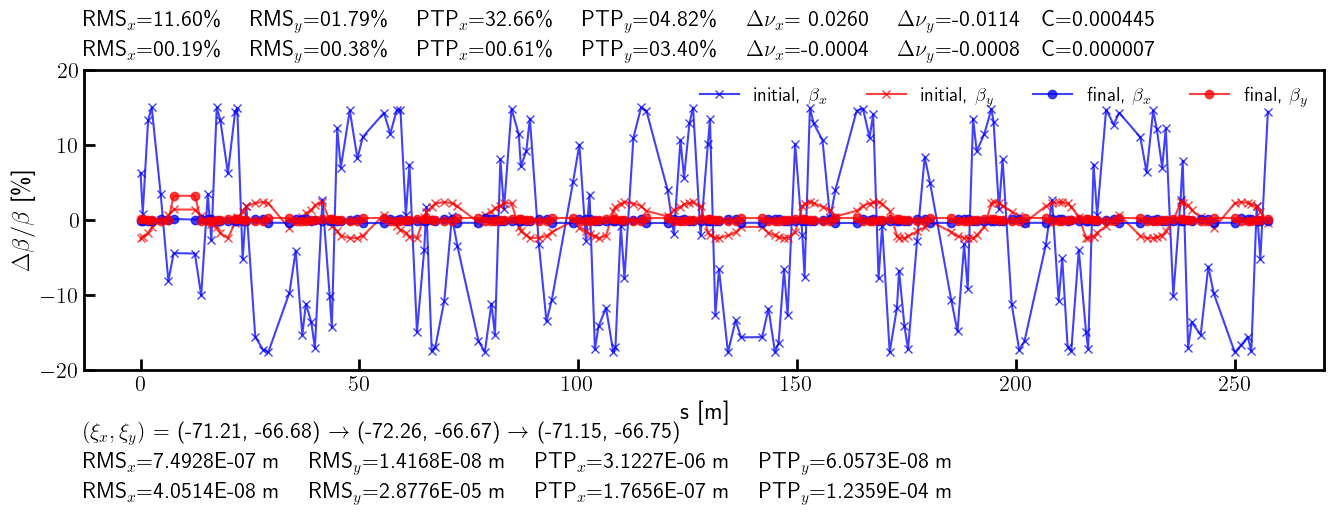

In [47]:
# Beta-beating

bx_ref_bb = 100.0*(bx - bx_id)    / bx
by_ref_bb = 100.0*(by - by_id)    / by
bx_res_bb = 100.0*(bx - bx_result)/ bx
by_res_bb = 100.0*(by - by_result)/ by

def rms(x):
    return (x**2).mean().sqrt()

rms_x_ref = rms(bx_ref_bb).item()
ptp_x_ref = (bx_ref_bb.max() - bx_ref_bb.min()).item()
rms_y_ref = rms(by_ref_bb).item()
ptp_y_ref = (by_ref_bb.max() - by_ref_bb.min()).item()

rms_x_res = rms(bx_res_bb).item()
ptp_x_res = (bx_res_bb.max() - bx_res_bb.min()).item()
rms_y_res = rms(by_res_bb).item()
ptp_y_res = (by_res_bb.max() - by_res_bb.min()).item()

s = ring.locations().cpu().numpy()
bx_ref_np = bx_ref_bb.cpu().numpy()
by_ref_np = by_ref_bb.cpu().numpy()
bx_res_np = bx_res_bb.cpu().numpy()
by_res_np = by_res_bb.cpu().numpy()

etax_ref = etaqx - etaqx_id
etay_ref = etaqy - etaqy_id
etax_res = etaqx - etaqx_result
etay_res = etaqy - etaqy_result

rms_etax_ref = rms(etax_ref).item()
ptp_etax_ref = (etax_ref.max() - etax_ref.min()).item()
rms_etay_ref = rms(etay_ref).item()
ptp_etay_ref = (etay_ref.max() - etay_ref.min()).item()

rms_etax_res = rms(etax_res).item()
ptp_etax_res = (etax_res.max() - etax_res.min()).item()
rms_etay_res = rms(etay_res).item()
ptp_etay_res = (etay_res.max() - etay_res.min()).item()

etax_ref_np = etax_ref.cpu().numpy()
etay_ref_np = etay_ref.cpu().numpy()
etax_res_np = etax_res.cpu().numpy()
etay_res_np = etay_res.cpu().numpy()


fig, ax = plt.subplots(
    1, 1, figsize=(16, 6),
    sharex=True,
    gridspec_kw={'hspace': 0.3}
)

fig.subplots_adjust(top=0.85, bottom=0.35)

ax.errorbar(s, bx_ref_np, fmt='-', marker='x', color='blue', alpha=0.75, lw=1.5, label=r'initial, $\beta_x$')
ax.errorbar(s, by_ref_np, fmt='-', marker='x', color='red',  alpha=0.75, lw=1.5, label=r'initial, $\beta_y$')
ax.errorbar(s, bx_res_np, fmt='-', marker='o', color='blue', alpha=0.75, lw=1.5, label=r'final, $\beta_x$')
ax.errorbar(s, by_res_np, fmt='-', marker='o', color='red',  alpha=0.75, lw=1.5, label=r'final, $\beta_y$')
ax.set_xlabel('s [m]', fontsize=18)
ax.set_ylabel(r'$\Delta \beta / \beta$ [\%]', fontsize=18)
ax.tick_params(width=2, labelsize=16)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')
title = (
    rf'RMS$_x$={rms_x_ref:05.2f}\% \quad RMS$_y$={rms_y_ref:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_ref:05.2f}\% \quad PTP$_y$={ptp_y_ref:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_id)}{(nux - nux_id).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_id)}{(nuy - nuy_id).abs().item():.4f}'
    rf'\quad C={c_id.item():.6f}'
)
ax.text(0.0, 1.125, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'RMS$_x$={rms_x_res:05.2f}\% \quad RMS$_y$={rms_y_res:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_res:05.2f}\% \quad PTP$_y$={ptp_y_res:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_result)}{(nux - nux_result).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_result)}{(nuy - nuy_result).abs().item():.4f}'
    rf'\quad C={c_result.item():.6f}'
)
ax.text(0.0, 1.025, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'$(\xi_x, \xi_y)$ = ({psi_x.item():.2f}, {psi_y.item():.2f}) $\to$ ({psi_id_x.item():.2f}, {psi_id_y.item():.2f}) $\to$ ({psi_result_x.item():.2f}, {psi_result_y.item():.2f})' 
)
ax.text(0.0, -0.25 - 0*0.1, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'RMS$_x$={rms_etax_ref:.4E} m \quad RMS$_y$={rms_etay_ref:.4E} m  \quad '
    rf'PTP$_x$={ptp_etax_ref:.4E} m \quad PTP$_y$={ptp_etay_ref:.4E} m  \quad '
)
ax.text(0.0, -0.25 - 1*0.1, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'RMS$_x$={rms_etax_res:.4E} m  \quad RMS$_y$={rms_etay_res:.4E} m  \quad '
    rf'PTP$_x$={ptp_etax_res:.4E} m  \quad PTP$_y$={ptp_etay_res:.4E} m  \quad '
)
ax.text(0.0, -0.25 - 2*0.1, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

ax.legend(loc='upper right', frameon=False, fontsize=14, ncol=4)
ax.set_ylim(-20, 20)

plt.setp(ax.spines.values(), linewidth=2.0)
plt.show()

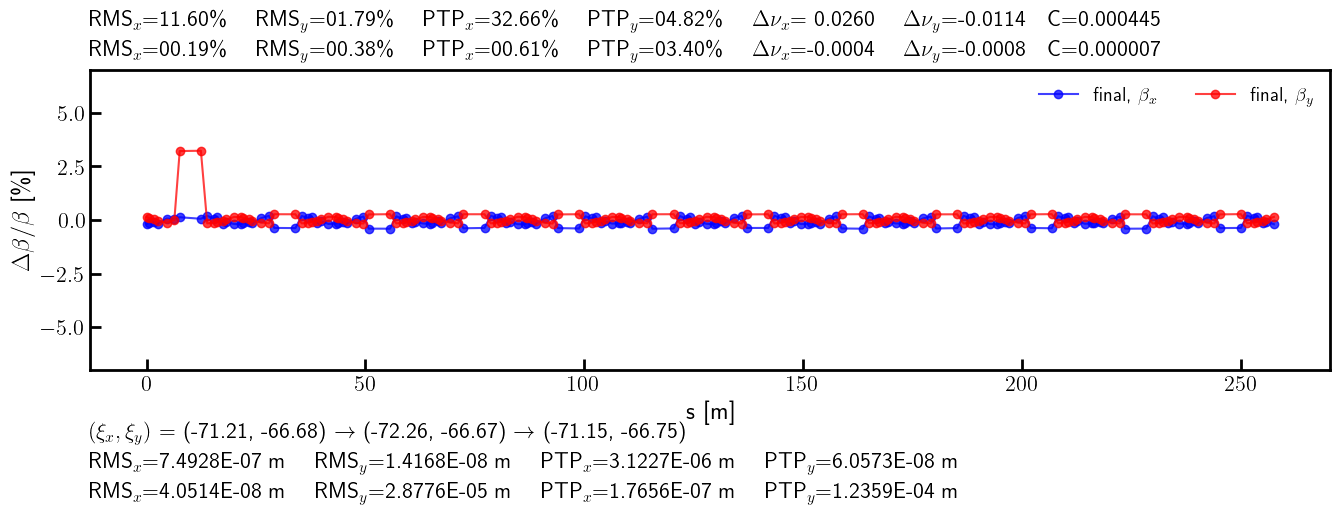

In [48]:
# Beta-beating

bx_ref_bb = 100.0*(bx - bx_id)    / bx
by_ref_bb = 100.0*(by - by_id)    / by
bx_res_bb = 100.0*(bx - bx_result)/ bx
by_res_bb = 100.0*(by - by_result)/ by

def rms(x):
    return (x**2).mean().sqrt()

rms_x_ref = rms(bx_ref_bb).item()
ptp_x_ref = (bx_ref_bb.max() - bx_ref_bb.min()).item()
rms_y_ref = rms(by_ref_bb).item()
ptp_y_ref = (by_ref_bb.max() - by_ref_bb.min()).item()

rms_x_res = rms(bx_res_bb).item()
ptp_x_res = (bx_res_bb.max() - bx_res_bb.min()).item()
rms_y_res = rms(by_res_bb).item()
ptp_y_res = (by_res_bb.max() - by_res_bb.min()).item()

s = ring.locations().cpu().numpy()
bx_ref_np = bx_ref_bb.cpu().numpy()
by_ref_np = by_ref_bb.cpu().numpy()
bx_res_np = bx_res_bb.cpu().numpy()
by_res_np = by_res_bb.cpu().numpy()

etax_ref = etaqx - etaqx_id
etay_ref = etaqy - etaqy_id
etax_res = etaqx - etaqx_result
etay_res = etaqy - etaqy_result

rms_etax_ref = rms(etax_ref).item()
ptp_etax_ref = (etax_ref.max() - etax_ref.min()).item()
rms_etay_ref = rms(etay_ref).item()
ptp_etay_ref = (etay_ref.max() - etay_ref.min()).item()

rms_etax_res = rms(etax_res).item()
ptp_etax_res = (etax_res.max() - etax_res.min()).item()
rms_etay_res = rms(etay_res).item()
ptp_etay_res = (etay_res.max() - etay_res.min()).item()

etax_ref_np = etax_ref.cpu().numpy()
etay_ref_np = etay_ref.cpu().numpy()
etax_res_np = etax_res.cpu().numpy()
etay_res_np = etay_res.cpu().numpy()


fig, ax = plt.subplots(
    1, 1, figsize=(16, 6),
    sharex=True,
    gridspec_kw={'hspace': 0.3}
)

fig.subplots_adjust(top=0.85, bottom=0.35)

# ax.errorbar(s, bx_ref_np, fmt='-', marker='x', color='blue', alpha=0.75, lw=1.5, label=r'initial, $\beta_x$')
# ax.errorbar(s, by_ref_np, fmt='-', marker='x', color='red',  alpha=0.75, lw=1.5, label=r'initial, $\beta_y$')
ax.errorbar(s, bx_res_np, fmt='-', marker='o', color='blue', alpha=0.75, lw=1.5, label=r'final, $\beta_x$')
ax.errorbar(s, by_res_np, fmt='-', marker='o', color='red',  alpha=0.75, lw=1.5, label=r'final, $\beta_y$')
ax.set_xlabel('s [m]', fontsize=18)
ax.set_ylabel(r'$\Delta \beta / \beta$ [\%]', fontsize=18)
ax.tick_params(width=2, labelsize=16)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')
title = (
    rf'RMS$_x$={rms_x_ref:05.2f}\% \quad RMS$_y$={rms_y_ref:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_ref:05.2f}\% \quad PTP$_y$={ptp_y_ref:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_id)}{(nux - nux_id).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_id)}{(nuy - nuy_id).abs().item():.4f}'
    rf'\quad C={c_id.item():.6f}'
)
ax.text(0.0, 1.125, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'RMS$_x$={rms_x_res:05.2f}\% \quad RMS$_y$={rms_y_res:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_res:05.2f}\% \quad PTP$_y$={ptp_y_res:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_result)}{(nux - nux_result).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_result)}{(nuy - nuy_result).abs().item():.4f}'
    rf'\quad C={c_result.item():.6f}'
)
ax.text(0.0, 1.025, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'$(\xi_x, \xi_y)$ = ({psi_x.item():.2f}, {psi_y.item():.2f}) $\to$ ({psi_id_x.item():.2f}, {psi_id_y.item():.2f}) $\to$ ({psi_result_x.item():.2f}, {psi_result_y.item():.2f})' 
)
ax.text(0.0, -0.25 - 0*0.1, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'RMS$_x$={rms_etax_ref:.4E} m \quad RMS$_y$={rms_etay_ref:.4E} m  \quad '
    rf'PTP$_x$={ptp_etax_ref:.4E} m \quad PTP$_y$={ptp_etay_ref:.4E} m  \quad '
)
ax.text(0.0, -0.25 - 1*0.1, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'RMS$_x$={rms_etax_res:.4E} m  \quad RMS$_y$={rms_etay_res:.4E} m  \quad '
    rf'PTP$_x$={ptp_etax_res:.4E} m  \quad PTP$_y$={ptp_etay_res:.4E} m  \quad '
)
ax.text(0.0, -0.25 - 2*0.1, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

ax.legend(loc='upper right', frameon=False, fontsize=14, ncol=4)
ax.set_ylim(-7, 7)

plt.setp(ax.spines.values(), linewidth=2.0)
plt.show()

In [49]:
# Initial and final values

QF = [f'QF_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]
QD = [f'QD_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]

nkn = ['OCT_S01_02', 'QF_S01_02', 'QD_S01_02', 'QD_S01_03', 'QF_S01_03', 'OCT_S01_03']
nks = ['SD_S01_05', 'SH_S01_02', 'SH_S01_03', 'SD_S01_06']

ring.flatten()

kni = {name: ring[name].kn.item() for name in nkn}
ksi = {name: ring[name].ks.item() for name in nks}
kfi = {name: ring[name].kn.item() for name in QF}
kdi = {name: ring[name].kn.item() for name in QD}

ring.splice()

error.flatten()

knf = {name: error[name].kn.item() for name in nkn}
ksf = {name: error[name].ks.item() for name in nks}
kff = {name: error[name].kn.item() for name in QF}
kdf = {name: error[name].kn.item() for name in QD}

error.splice()

In [50]:
# Global

gkfi = [kfi[name] for name in kfi if name not in nkn]
gkdi = [kdi[name] for name in kdi if name not in nkn]
gkfi, *_ = gkfi
gkdi, *_ = gkdi

gkff = [kff[name] for name in kff if name not in nkn]
gkdf = [kdf[name] for name in kdf if name not in nkn]
gkff, *_ = gkff
gkdf, *_ = gkdf

dkf = [(kff[name] - kfi[name]) for name in kfi if name not in nkn]
dkd = [(kdf[name] - kdi[name]) for name in kdi if name not in nkn]
dkf_abs, *_ = dkf
dkd_abs, *_ = dkd
gk_abs = {'DKF': dkf_abs, 'DKD': dkd_abs}

dkf = [(kff[name]/kfi[name] - 1) for name in kfi if name not in nkn]
dkd = [(kdf[name]/kdi[name] - 1) for name in kdi if name not in nkn]
dkf_fse, *_ = dkf
dkd_fse, *_ = dkd
gk_fse = {'DKF': dkf_fse, 'DKD': dkd_fse}

print(gk_abs)
print(gk_fse)

{'DKF': -0.022554396798479814, 'DKD': 0.061526790825143785}
{'DKF': -0.004116210289564881, 'DKD': -0.018532165911187892}


In [51]:
# Local

dkn_fse = {name: knf[name]/kni[name] - 1 for name in kni}
dkn_abs = {name: knf[name] - kni[name]for name in kni}

dks_fse = {name: 0 for name in ksi}
dks_abs = {name: ksf[name] - ksi[name] for name in ksi}

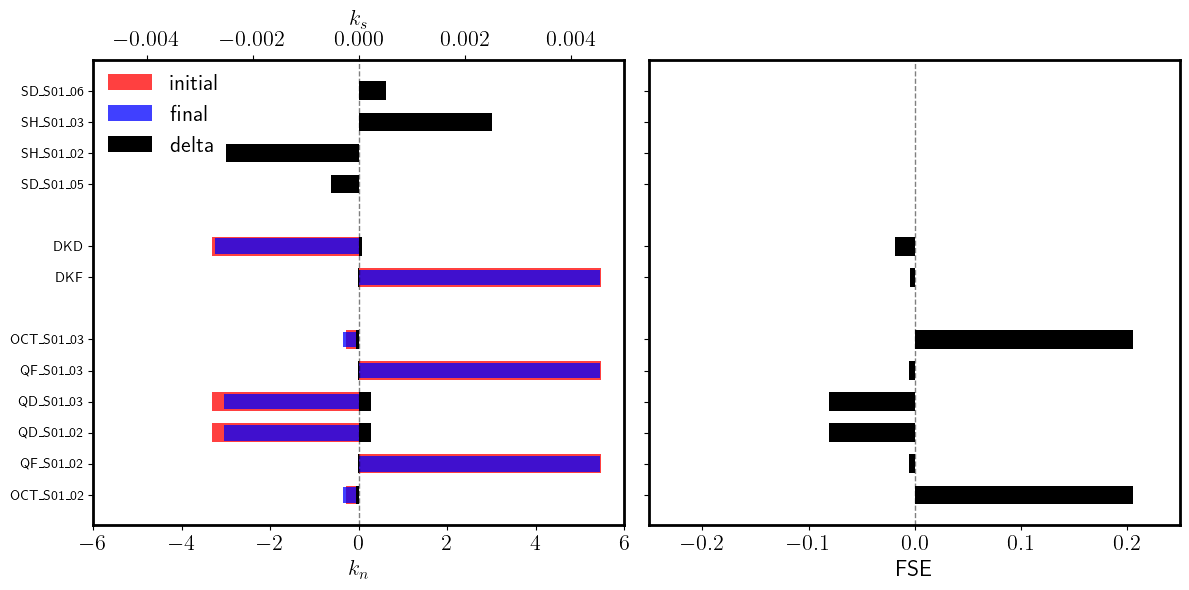

In [52]:
import numpy as np
import matplotlib.pyplot as plt

gap = 1

n_kn = len(dkn_abs)
n_dk = len(gk_abs)
n_ks = len(dks_abs)

y_kn = np.arange(n_kn)
y_dk = np.arange(n_dk) + n_kn + gap
y_ks = np.arange(n_ks) + n_kn + n_dk + 2*gap

yticks = np.concatenate([y_kn, y_dk, y_ks])
yticklabels = [*kni.keys()] + [*gk_abs.keys()] + [*ksi.keys()]

fig, (ax_abs, ax_fse) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

ax_abs.barh(y_dk, [gkfi, gkdi], height=0.6, color='red',   alpha=0.75, label='initial')
ax_abs.barh(y_dk, [gkff, gkdf], height=0.5, color='blue',   alpha=0.75, label='final')
ax_abs.barh(y_dk, [gk_abs['DKF'], gk_abs['DKD']], height=0.6, color='black',   alpha=1, label='delta')

ax_abs.barh(y_kn, kni.values(), height=0.6, color='red',   alpha=0.75)
ax_abs.barh(y_kn, knf.values(), height=0.5, color='blue',   alpha=0.75)
ax_abs.barh(y_kn, list(dkn_abs.values()), height=0.6, color='black', alpha=1)
ax_abs.legend(loc=(0.01, 0.775), frameon=False, fontsize=16, ncol=1)
ax_abs.set_xlim(-6, 6)
ax_abs.set_xlabel(r'$k_n$', fontsize=16)
ax_abs.tick_params(axis='x', labelsize=16)
ax_abs = ax_abs.twiny()
ax_abs.barh(y_ks, ksi.values(), height=0.6, color='red',   alpha=0.75)
ax_abs.barh(y_ks, ksf.values(), height=0.5, color='blue',   alpha=0.75)
ax_abs.barh(y_ks, list(dks_abs.values()), height=0.6, color='black', alpha=1)
ax_abs.set_xlim(-0.005, 0.005)
ax_abs.set_yticks(yticks)
ax_abs.set_yticklabels(yticklabels, fontsize=16)
ax_abs.axvline(0.0, color='black', linewidth=1.0, linestyle='--', alpha=0.5)
ax_abs.set_xlabel(r'$k_s$', fontsize=16)
ax_abs.tick_params(axis='x', labelsize=16)
ax_abs.tick_params(axis='y', labelsize=16)

ax_fse.barh(y_dk, gk_fse.values(), height=0.6, color='black',  alpha=1)
ax_fse.barh(y_kn, dkn_fse.values(), height=0.6, color='black',   alpha=1)
ax_fse.set_xlim(-25/100, 25/100)
ax_fse.axvline(0.0, color='black', linewidth=1.0, linestyle='--', alpha=0.5)
ax_fse.set_xlabel(r'FSE', fontsize=16)
ax_fse.tick_params(axis='x', labelsize=16)
ax_fse.tick_params(axis='y', labelsize=16)

plt.setp(ax_abs.spines.values(), linewidth=2.0)
plt.setp(ax_fse.spines.values(), linewidth=2.0)

plt.tight_layout()
plt.show()

### orm (local)

In [1]:
# Import

import torch
from torch import Tensor

from pathlib import Path

import matplotlib
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
matplotlib.rcParams['text.usetex'] = True

from model.library.element import Element
from model.library.line import Line
from model.library.corrector import Corrector
from model.library.quadrupole import Quadrupole
from model.library.matrix import Matrix

from model.command.external import load_lattice
from model.command.build import build
from model.command.tune import tune
from model.command.tune import chromaticity
from model.command.orbit import dispersion
from model.command.orbit import ORM
from model.command.twiss import twiss
from model.command.advance import advance
from model.command.coupling import coupling

from model.command.wrapper import Wrapper
from model.command.wrapper import forward
from model.command.wrapper import inverse
from model.command.wrapper import normalize

In [2]:
# Set data type and device

Element.dtype = dtype = torch.float64
Element.device = device = torch.device('cpu')

In [3]:
# Load lattice (ELEGANT table)
# Note, lattice is allowed to have repeated elements

path = Path('elettra.lte')
data = load_lattice(path)

In [4]:
# Build and setup lattice

ring:Line = build('RING', 'ELEGANT', data)

# Flatten sublines

ring.flatten()

# Remove all marker elements but the ones starting with MLL (long straight section centers)

ring.remove_group(pattern=r'^(?!MLL_).*', kinds=['Marker'])

# Replace all sextupoles with quadrupoles


def factory(element:Element) -> None:
    table = element.serialize
    table.pop('ms', None)
    return Quadrupole(**table)

ring.replace_group(pattern=r'', factory=factory, kinds=['Sextupole'])

# Set linear dipoles

def apply(element:Element) -> None:
    element.linear = True

ring.apply(apply, kinds=['Dipole'])

# Insert correctors

for name, *_ in ring.layout():
    if name.startswith('CH'):
        corrector = Corrector(f'{name}_CXY', factor=1)
        ring.split((1 + 1, None, [name], None), paste=[corrector])

# Merge drifts

ring.merge()

# Change lattice start start

ring.start = "BPM_S01_01"

# Split BPMs

ring.split((None, ['BPM'], None, None))

# Roll lattice

ring.roll(1)

# Splice

ring.splice()

# Describe

ring.describe

{'BPM': 168,
 'Drift': 732,
 'Dipole': 156,
 'Quadrupole': 360,
 'Corrector': 24,
 'Marker': 12}

In [5]:
# Compute tunes (fractional part)

nux, nuy = tune(ring, [], matched=True, limit=1)

In [6]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx, etapx, etaqy, etapy = dispersion(ring, orbit, [], limit=1)

In [7]:
# Compute twiss parameters

ax, bx, ay, by = twiss(ring, [], matched=True, advance=True, full=False).T

In [8]:
# Compute phase advances

mux, muy = advance(ring, [], alignment=False, matched=True).T

In [9]:
# Compute coupling

c = coupling(ring, [])

In [10]:
# Compute chromaticity

psi = chromaticity(ring, [])

In [11]:
# Quadrupole names for global tune correction

QF = [f'QF_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]
QD = [f'QD_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]

In [12]:
# Several local knobs can be used to correct ID effects

# Normal quadrupole correctors

nkn = ['OCT_S01_02', 'QF_S01_02', 'QD_S01_02', 'QD_S01_03', 'QF_S01_03', 'OCT_S01_03']

# Skew quadrupole correctors

nks = ['SD_S01_05', 'SH_S01_02', 'SH_S01_03', 'SD_S01_06']

In [13]:
# Define knobs to magnets mixing matrices

Sn = torch.tensor([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0], [0.0, 0.0, 1.0], [0.0, 1.0, 0.0], [1.0, 0.0, 0.0]], dtype=dtype)

print(Sn)
print()

Ss = torch.tensor([[+1.0, 0.0], [0.0, +1.0], [0.0, -1.0], [-1.0, 0.0]], dtype=dtype)

print(Ss)
print()

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.]], dtype=torch.float64)

tensor([[ 1.,  0.],
        [ 0.,  1.],
        [ 0., -1.],
        [-1.,  0.]], dtype=torch.float64)



In [14]:
# Define observables for 'mixed' knobs

def knobs_split(knobs):
    kn, ks = torch.split(knobs, [3, 2])
    kn = Sn @ kn
    ks = Ss @ ks
    return kn, ks


def knobs_build(knobs):
    kn, ks = knobs_split(knobs)
    return (nkn, kn), (nks, ks)


def observable_orm(nn, kn, ns, ks):
    orm = ORM(ring, orbit,  [kn, ks], ('kn', None, nn, None), ('ks', None, ns, None), limit=1)
    return orm


def observable(knobs):
    (nn, kn), (ns, ks) = knobs_build(knobs)
    orm = observable_orm(nn, kn, ns, ks)
    return orm.flatten()

In [15]:
# Compute target vector and corresponding responce matrix

knobs = torch.tensor((3 + 2)*[0.0], dtype=dtype)
target = observable(knobs)
matrix = torch.func.jacfwd(observable)(knobs)

print(knobs.shape)
print(target.shape)
print(matrix.shape)
print(torch.linalg.matrix_rank(matrix))

torch.Size([5])
torch.Size([16128])
torch.Size([16128, 5])
tensor(5)


In [16]:
# Define ID model
# Note, only the flattened triangular part of the A and B matrices is passed

A = torch.tensor([[-0.03484222052711237, 1.0272120741819959E-7, -4.698931299341201E-9, 0.0015923185492594811],
                  [1.0272120579834892E-7, -0.046082787920135176, 0.0017792061173117564, 3.3551298301095784E-8],
                  [-4.6989312853101E-9, 0.0017792061173117072, 0.056853750760983084, -1.5929605363332683E-7],
                  [0.0015923185492594336, 3.3551298348653296E-8, -1.5929605261642905E-7, 0.08311631737263032]], dtype=dtype)

B = torch.tensor([[0.03649353186115209, 0.0015448347221877217, 0.00002719892025520868, -0.0033681183134964482],
                  [0.0015448347221877217, 0.13683886657005795, -0.0033198692682377406, 0.00006140578258682469],
                  [0.00002719892025520868, -0.0033198692682377406, -0.05260095308967722, 0.005019907688182885],
                  [-0.0033681183134964482, 0.00006140578258682469, 0.005019907688182885, -0.2531573249456863]], dtype=dtype)

ID = Matrix('ID', 
            length=0.0, 
            A=A[torch.triu(torch.ones_like(A, dtype=torch.bool))].tolist(), 
            B=B[torch.triu(torch.ones_like(B, dtype=torch.bool))].tolist())

In [17]:
# Insert ID into the existing lattice
# This will replace the target marker

error = ring.clone()
error.flatten()
error.insert(ID, error.next('MLL_S01').name, position=0.0)
error.splice()

# Describe

error.describe

{'BPM': 168,
 'Drift': 733,
 'Dipole': 156,
 'Quadrupole': 360,
 'Corrector': 24,
 'Marker': 12,
 'Matrix': 1}

In [18]:
# Compute tunes (fractional part)

nux_id, nuy_id = tune(error, [], matched=True, limit=1)

In [19]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id, etapx_id, etaqy_id, etapy_id = dispersion(error, orbit, [], limit=1)

In [20]:
# Compute twiss parameters

ax_id, bx_id, ay_id, by_id = twiss(error, [], matched=True, advance=True, full=False).T

In [21]:
# Compute phase advances

mux_id, muy_id = advance(error, [], alignment=False, matched=True).T

In [22]:
# Compute coupling

c_id = coupling(error, [])

In [23]:
# Compute chromaticity

psi_id = chromaticity(error, [])

In [24]:
# Tune shifts

print((nux - nux_id))
print((nuy - nuy_id))

tensor(0.0260, dtype=torch.float64)
tensor(-0.0114, dtype=torch.float64)


In [25]:
# Coupling (minimal tune distance)

print(c)
print(c_id)

tensor(0., dtype=torch.float64)
tensor(0.0004, dtype=torch.float64)


In [26]:
# Chromaticity

print(psi)
print(psi_id)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-72.2597, -66.6681], dtype=torch.float64)


In [27]:
# Define parametric observable vector (emulate tune measurement)

def observable_orm(nn, kn, ns, ks):
    orm = ORM(error, orbit,  [kn, ks], ('kn', None, nn, None), ('ks', None, ns, None), limit=1)
    return orm

def observable(knobs):
    (nn, kn), (ns, ks) = knobs_build(knobs)
    orm = observable_orm(nn, kn, ns, ks)
    return orm.flatten()

In [28]:
# Check the residual vector norm

knobs = torch.tensor((3 + 2)*[0.0], dtype=dtype)

print(((observable(knobs) - target)**2).sum())

tensor(1498.9104, dtype=torch.float64)


In [29]:
# Optimization loop (model free)

# Responce matrix (jacobian)

M = matrix.clone()

# Weighting covariance (sensitivity) matrix

epsilon = 1.0E-9
C = M @ M.T
C = C + epsilon*torch.eye(len(C), dtype=dtype)

# Cholesky decomposition

L = torch.linalg.cholesky(C) 

# Whiten response

M = torch.linalg.solve_triangular(L, M, upper=False)

# Additional weights
# Can be used to extra weight selected observables, e.g. tunes

weights = torch.ones(len(M), dtype=dtype)
weights = weights.sqrt()

# Whiten response with additional weights

M = M*weights.unsqueeze(1)

# Iterative correction

lr = 0.75

# Initial value

knobs = torch.tensor((3 + 2)*[0.0], dtype=dtype)

# Correction loop

for _ in range(16):
    value = observable(knobs)
    residual = target - value
    residual = torch.linalg.solve_triangular(L, residual.unsqueeze(-1), upper=False).squeeze(-1)
    residual = residual*weights
    delta = torch.linalg.lstsq(M, residual, driver="gels").solution
    knobs += lr*delta
    print(((value - target)**2).sum())
print()

tensor(1498.9104, dtype=torch.float64)
tensor(94.2315, dtype=torch.float64)
tensor(27.2219, dtype=torch.float64)
tensor(14.5212, dtype=torch.float64)
tensor(11.7324, dtype=torch.float64)
tensor(11.2607, dtype=torch.float64)
tensor(11.2023, dtype=torch.float64)
tensor(11.1988, dtype=torch.float64)
tensor(11.1998, dtype=torch.float64)
tensor(11.2004, dtype=torch.float64)
tensor(11.2006, dtype=torch.float64)
tensor(11.2007, dtype=torch.float64)
tensor(11.2007, dtype=torch.float64)
tensor(11.2007, dtype=torch.float64)
tensor(11.2007, dtype=torch.float64)
tensor(11.2007, dtype=torch.float64)



In [30]:
# Knob values

(nn, kn), (ns, ks) = knobs_build(knobs)

print(kn.numpy())
print(ks.numpy())

[-0.03402113 -0.21871428  0.75520734  0.75520734 -0.21871428 -0.03402113]
[-0.00038598 -0.0024136   0.0024136   0.00038598]


In [31]:
# Apply final corrections

error.flatten()

print()
print('kn:')
for name, knob in zip(nn, kn):
    print(f'{name:<10}: {knob.numpy():>20}: {error[name].kn.numpy():>20} -> {(error[name].kn + knob).numpy():>20}, FSE: {((error[name].kn + knob)/error[name].kn - 1).numpy():>20}')
    error[name].kn = (error[name].kn + knob).item()

print()
print('ks:')
for name, knob in zip(ns, ks):
    print(f'{name:<10}: {knob.numpy():>20}: {error[name].ks.numpy():>20} -> {(error[name].ks + knob).numpy():>20}')
    error[name].ks = (error[name].ks + knob).item()
    
error.splice()


kn:
OCT_S01_02: -0.03402112810450709: -0.29359999999999903 ->  -0.3276211281045061, FSE:  0.11587577692270834
QF_S01_02 :  -0.2187142761729715:    5.479408293511701 ->    5.260694017338729, FSE: -0.039915674185469374
QD_S01_02 :    0.755207336457441:   -3.319999999999998 ->   -2.564792663542557, FSE:  -0.2274720892944101
QD_S01_03 :    0.755207336457441:   -3.319999999999998 ->   -2.564792663542557, FSE:  -0.2274720892944101
QF_S01_03 :  -0.2187142761729715:    5.479408293511701 ->    5.260694017338729, FSE: -0.039915674185469374
OCT_S01_03: -0.03402112810450709: -0.29359999999999903 ->  -0.3276211281045061, FSE:  0.11587577692270834

ks:
SD_S01_05 : -0.0003859825140469747:                  0.0 -> -0.0003859825140469747
SH_S01_02 : -0.002413604312380506:                  0.0 -> -0.002413604312380506
SH_S01_03 : 0.002413604312380506:                  0.0 -> 0.002413604312380506
SD_S01_06 : 0.0003859825140469747:                  0.0 -> 0.0003859825140469747


In [32]:
# Compute tunes (fractional part)

nux_result, nuy_result = tune(error, [], matched=True, limit=1)

In [33]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_result, etapx_result, etaqy_result, etapy_result = dispersion(error, orbit, [], limit=1)

In [34]:
# Compute twiss parameters

ax_result, bx_result, ay_result, by_result = twiss(error, [], matched=True, advance=True, full=False).T

In [35]:
# Compute phase advances

mux_result, muy_result = advance(error, [], alignment=False, matched=True).T

In [36]:
# Compute coupling

c_result = coupling(error, [])

In [37]:
# Compute chromaticity

psi_result = chromaticity(error, [])

In [38]:
# Tune shifts

print((nux - nux_id).abs())
print((nuy - nuy_id).abs())
print()

print((nux - nux_result).abs())
print((nuy - nuy_result).abs())
print()

tensor(0.0260, dtype=torch.float64)
tensor(0.0114, dtype=torch.float64)

tensor(0.0003, dtype=torch.float64)
tensor(0.0002, dtype=torch.float64)



In [39]:
# Coupling (minimal tune distance)

print(c)
print(c_id)
print(c_result)

tensor(0., dtype=torch.float64)
tensor(0.0004, dtype=torch.float64)
tensor(7.5546e-06, dtype=torch.float64)


In [40]:
# Chromaticity

(psi_x, psi_y) = psi
(psi_id_x, psi_id_y) = psi_id
(psi_result_x, psi_result_y) =psi_result

print(psi_x, psi_y)
print(psi_id_x, psi_id_y)
print(psi_result_x, psi_result_y)

tensor(-71.2093, dtype=torch.float64) tensor(-66.6787, dtype=torch.float64)
tensor(-72.2597, dtype=torch.float64) tensor(-66.6681, dtype=torch.float64)
tensor(-71.1664, dtype=torch.float64) tensor(-66.6784, dtype=torch.float64)


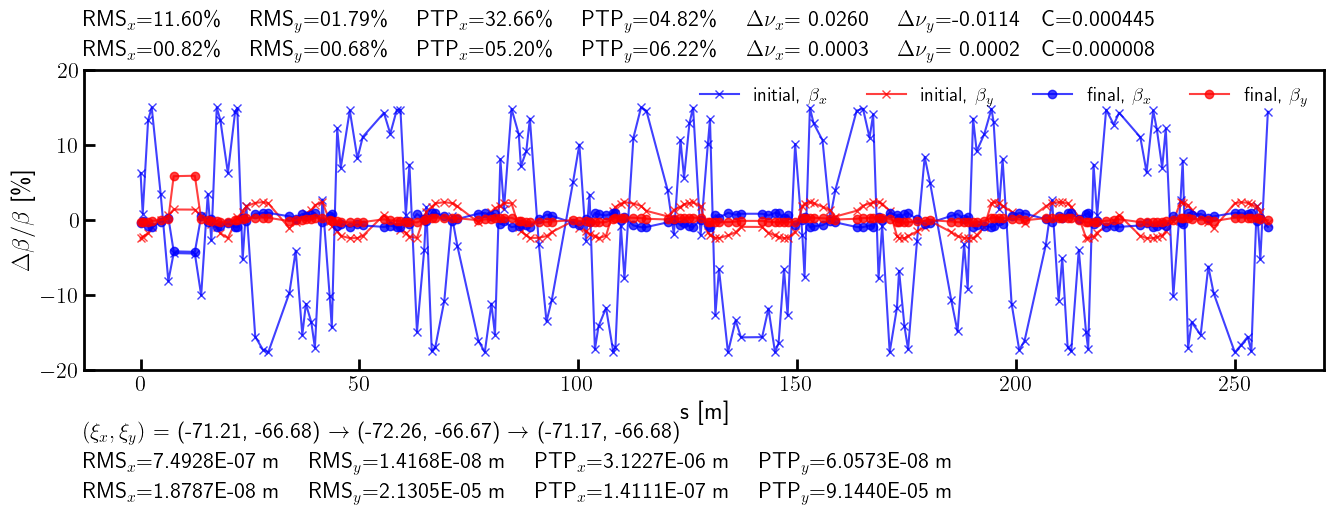

In [41]:
# Beta-beating

bx_ref_bb = 100.0*(bx - bx_id)    / bx
by_ref_bb = 100.0*(by - by_id)    / by
bx_res_bb = 100.0*(bx - bx_result)/ bx
by_res_bb = 100.0*(by - by_result)/ by

def rms(x):
    return (x**2).mean().sqrt()

rms_x_ref = rms(bx_ref_bb).item()
ptp_x_ref = (bx_ref_bb.max() - bx_ref_bb.min()).item()
rms_y_ref = rms(by_ref_bb).item()
ptp_y_ref = (by_ref_bb.max() - by_ref_bb.min()).item()

rms_x_res = rms(bx_res_bb).item()
ptp_x_res = (bx_res_bb.max() - bx_res_bb.min()).item()
rms_y_res = rms(by_res_bb).item()
ptp_y_res = (by_res_bb.max() - by_res_bb.min()).item()

s = ring.locations().cpu().numpy()
bx_ref_np = bx_ref_bb.cpu().numpy()
by_ref_np = by_ref_bb.cpu().numpy()
bx_res_np = bx_res_bb.cpu().numpy()
by_res_np = by_res_bb.cpu().numpy()

etax_ref = etaqx - etaqx_id
etay_ref = etaqy - etaqy_id
etax_res = etaqx - etaqx_result
etay_res = etaqy - etaqy_result

rms_etax_ref = rms(etax_ref).item()
ptp_etax_ref = (etax_ref.max() - etax_ref.min()).item()
rms_etay_ref = rms(etay_ref).item()
ptp_etay_ref = (etay_ref.max() - etay_ref.min()).item()

rms_etax_res = rms(etax_res).item()
ptp_etax_res = (etax_res.max() - etax_res.min()).item()
rms_etay_res = rms(etay_res).item()
ptp_etay_res = (etay_res.max() - etay_res.min()).item()

etax_ref_np = etax_ref.cpu().numpy()
etay_ref_np = etay_ref.cpu().numpy()
etax_res_np = etax_res.cpu().numpy()
etay_res_np = etay_res.cpu().numpy()


fig, ax = plt.subplots(
    1, 1, figsize=(16, 6),
    sharex=True,
    gridspec_kw={'hspace': 0.3}
)

fig.subplots_adjust(top=0.85, bottom=0.35)

ax.errorbar(s, bx_ref_np, fmt='-', marker='x', color='blue', alpha=0.75, lw=1.5, label=r'initial, $\beta_x$')
ax.errorbar(s, by_ref_np, fmt='-', marker='x', color='red',  alpha=0.75, lw=1.5, label=r'initial, $\beta_y$')
ax.errorbar(s, bx_res_np, fmt='-', marker='o', color='blue', alpha=0.75, lw=1.5, label=r'final, $\beta_x$')
ax.errorbar(s, by_res_np, fmt='-', marker='o', color='red',  alpha=0.75, lw=1.5, label=r'final, $\beta_y$')
ax.set_xlabel('s [m]', fontsize=18)
ax.set_ylabel(r'$\Delta \beta / \beta$ [\%]', fontsize=18)
ax.tick_params(width=2, labelsize=16)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')
title = (
    rf'RMS$_x$={rms_x_ref:05.2f}\% \quad RMS$_y$={rms_y_ref:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_ref:05.2f}\% \quad PTP$_y$={ptp_y_ref:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_id)}{(nux - nux_id).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_id)}{(nuy - nuy_id).abs().item():.4f}'
    rf'\quad C={c_id.item():.6f}'
)
ax.text(0.0, 1.125, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'RMS$_x$={rms_x_res:05.2f}\% \quad RMS$_y$={rms_y_res:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_res:05.2f}\% \quad PTP$_y$={ptp_y_res:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_result)}{(nux - nux_result).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_result)}{(nuy - nuy_result).abs().item():.4f}'
    rf'\quad C={c_result.item():.6f}'
)
ax.text(0.0, 1.025, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'$(\xi_x, \xi_y)$ = ({psi_x.item():.2f}, {psi_y.item():.2f}) $\to$ ({psi_id_x.item():.2f}, {psi_id_y.item():.2f}) $\to$ ({psi_result_x.item():.2f}, {psi_result_y.item():.2f})' 
)
ax.text(0.0, -0.25 - 0*0.1, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'RMS$_x$={rms_etax_ref:.4E} m \quad RMS$_y$={rms_etay_ref:.4E} m  \quad '
    rf'PTP$_x$={ptp_etax_ref:.4E} m \quad PTP$_y$={ptp_etay_ref:.4E} m  \quad '
)
ax.text(0.0, -0.25 - 1*0.1, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'RMS$_x$={rms_etax_res:.4E} m  \quad RMS$_y$={rms_etay_res:.4E} m  \quad '
    rf'PTP$_x$={ptp_etax_res:.4E} m  \quad PTP$_y$={ptp_etay_res:.4E} m  \quad '
)
ax.text(0.0, -0.25 - 2*0.1, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

ax.legend(loc='upper right', frameon=False, fontsize=14, ncol=4)
ax.set_ylim(-20, 20)

plt.setp(ax.spines.values(), linewidth=2.0)
plt.show()

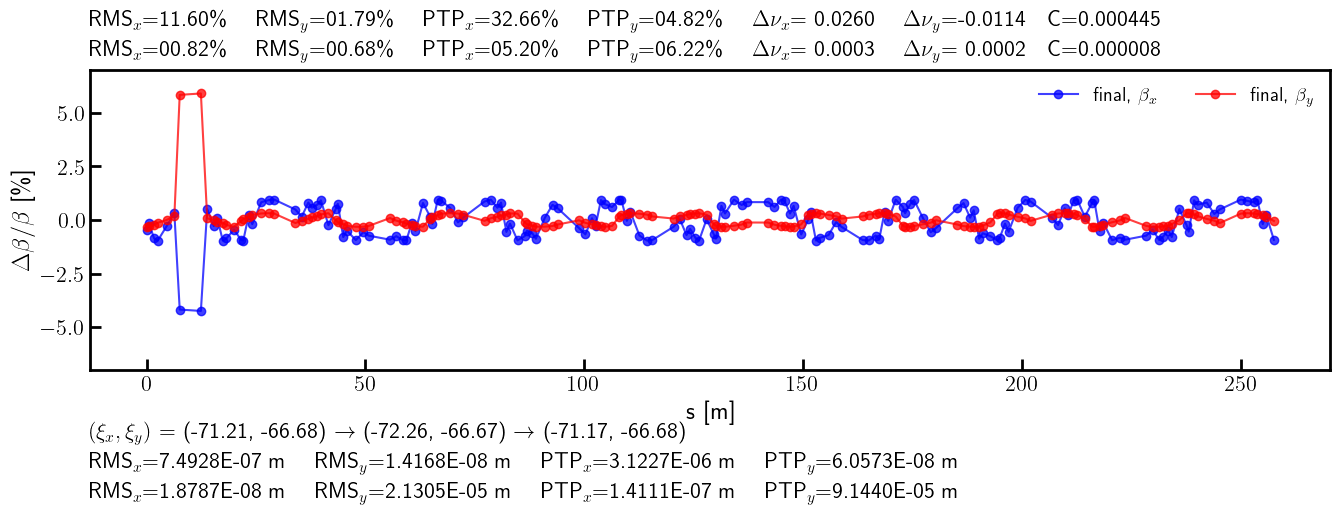

In [47]:
# Beta-beating

bx_ref_bb = 100.0*(bx - bx_id)    / bx
by_ref_bb = 100.0*(by - by_id)    / by
bx_res_bb = 100.0*(bx - bx_result)/ bx
by_res_bb = 100.0*(by - by_result)/ by

def rms(x):
    return (x**2).mean().sqrt()

rms_x_ref = rms(bx_ref_bb).item()
ptp_x_ref = (bx_ref_bb.max() - bx_ref_bb.min()).item()
rms_y_ref = rms(by_ref_bb).item()
ptp_y_ref = (by_ref_bb.max() - by_ref_bb.min()).item()

rms_x_res = rms(bx_res_bb).item()
ptp_x_res = (bx_res_bb.max() - bx_res_bb.min()).item()
rms_y_res = rms(by_res_bb).item()
ptp_y_res = (by_res_bb.max() - by_res_bb.min()).item()

s = ring.locations().cpu().numpy()
bx_ref_np = bx_ref_bb.cpu().numpy()
by_ref_np = by_ref_bb.cpu().numpy()
bx_res_np = bx_res_bb.cpu().numpy()
by_res_np = by_res_bb.cpu().numpy()

etax_ref = etaqx - etaqx_id
etay_ref = etaqy - etaqy_id
etax_res = etaqx - etaqx_result
etay_res = etaqy - etaqy_result

rms_etax_ref = rms(etax_ref).item()
ptp_etax_ref = (etax_ref.max() - etax_ref.min()).item()
rms_etay_ref = rms(etay_ref).item()
ptp_etay_ref = (etay_ref.max() - etay_ref.min()).item()

rms_etax_res = rms(etax_res).item()
ptp_etax_res = (etax_res.max() - etax_res.min()).item()
rms_etay_res = rms(etay_res).item()
ptp_etay_res = (etay_res.max() - etay_res.min()).item()

etax_ref_np = etax_ref.cpu().numpy()
etay_ref_np = etay_ref.cpu().numpy()
etax_res_np = etax_res.cpu().numpy()
etay_res_np = etay_res.cpu().numpy()


fig, ax = plt.subplots(
    1, 1, figsize=(16, 6),
    sharex=True,
    gridspec_kw={'hspace': 0.3}
)

fig.subplots_adjust(top=0.85, bottom=0.35)

# ax.errorbar(s, bx_ref_np, fmt='-', marker='x', color='blue', alpha=0.75, lw=1.5, label=r'initial, $\beta_x$')
# ax.errorbar(s, by_ref_np, fmt='-', marker='x', color='red',  alpha=0.75, lw=1.5, label=r'initial, $\beta_y$')
ax.errorbar(s, bx_res_np, fmt='-', marker='o', color='blue', alpha=0.75, lw=1.5, label=r'final, $\beta_x$')
ax.errorbar(s, by_res_np, fmt='-', marker='o', color='red',  alpha=0.75, lw=1.5, label=r'final, $\beta_y$')
ax.set_xlabel('s [m]', fontsize=18)
ax.set_ylabel(r'$\Delta \beta / \beta$ [\%]', fontsize=18)
ax.tick_params(width=2, labelsize=16)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')
title = (
    rf'RMS$_x$={rms_x_ref:05.2f}\% \quad RMS$_y$={rms_y_ref:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_ref:05.2f}\% \quad PTP$_y$={ptp_y_ref:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_id)}{(nux - nux_id).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_id)}{(nuy - nuy_id).abs().item():.4f}'
    rf'\quad C={c_id.item():.6f}'
)
ax.text(0.0, 1.125, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'RMS$_x$={rms_x_res:05.2f}\% \quad RMS$_y$={rms_y_res:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_res:05.2f}\% \quad PTP$_y$={ptp_y_res:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_result)}{(nux - nux_result).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_result)}{(nuy - nuy_result).abs().item():.4f}'
    rf'\quad C={c_result.item():.6f}'
)
ax.text(0.0, 1.025, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'$(\xi_x, \xi_y)$ = ({psi_x.item():.2f}, {psi_y.item():.2f}) $\to$ ({psi_id_x.item():.2f}, {psi_id_y.item():.2f}) $\to$ ({psi_result_x.item():.2f}, {psi_result_y.item():.2f})' 
)
ax.text(0.0, -0.25 - 0*0.1, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'RMS$_x$={rms_etax_ref:.4E} m \quad RMS$_y$={rms_etay_ref:.4E} m  \quad '
    rf'PTP$_x$={ptp_etax_ref:.4E} m \quad PTP$_y$={ptp_etay_ref:.4E} m  \quad '
)
ax.text(0.0, -0.25 - 1*0.1, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'RMS$_x$={rms_etax_res:.4E} m  \quad RMS$_y$={rms_etay_res:.4E} m  \quad '
    rf'PTP$_x$={ptp_etax_res:.4E} m  \quad PTP$_y$={ptp_etay_res:.4E} m  \quad '
)
ax.text(0.0, -0.25 - 2*0.1, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

ax.legend(loc='upper right', frameon=False, fontsize=14, ncol=4)
ax.set_ylim(-7, 7)

plt.setp(ax.spines.values(), linewidth=2.0)
plt.show()

In [43]:
# Initial and final values

QF = [f'QF_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]
QD = [f'QD_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]

nkn = ['OCT_S01_02', 'QF_S01_02', 'QD_S01_02', 'QD_S01_03', 'QF_S01_03', 'OCT_S01_03']
nks = ['SD_S01_05', 'SH_S01_02', 'SH_S01_03', 'SD_S01_06']

ring.flatten()

kni = {name: ring[name].kn.item() for name in nkn}
ksi = {name: ring[name].ks.item() for name in nks}
kfi = {name: ring[name].kn.item() for name in QF}
kdi = {name: ring[name].kn.item() for name in QD}

ring.splice()

error.flatten()

knf = {name: error[name].kn.item() for name in nkn}
ksf = {name: error[name].ks.item() for name in nks}
kff = {name: error[name].kn.item() for name in QF}
kdf = {name: error[name].kn.item() for name in QD}

error.splice()

In [44]:
# Global

gkfi = [kfi[name] for name in kfi if name not in nkn]
gkdi = [kdi[name] for name in kdi if name not in nkn]
gkfi, *_ = gkfi
gkdi, *_ = gkdi

gkff = [kff[name] for name in kff if name not in nkn]
gkdf = [kdf[name] for name in kdf if name not in nkn]
gkff, *_ = gkff
gkdf, *_ = gkdf

dkf = [(kff[name] - kfi[name]) for name in kfi if name not in nkn]
dkd = [(kdf[name] - kdi[name]) for name in kdi if name not in nkn]
dkf_abs, *_ = dkf
dkd_abs, *_ = dkd
gk_abs = {'DKF': dkf_abs, 'DKD': dkd_abs}

dkf = [(kff[name]/kfi[name] - 1) for name in kfi if name not in nkn]
dkd = [(kdf[name]/kdi[name] - 1) for name in kdi if name not in nkn]
dkf_fse, *_ = dkf
dkd_fse, *_ = dkd
gk_fse = {'DKF': dkf_fse, 'DKD': dkd_fse}

print(gk_abs)
print(gk_fse)

{'DKF': 0.0, 'DKD': 0.0}
{'DKF': 0.0, 'DKD': 0.0}


In [45]:
# Local

dkn_fse = {name: knf[name]/kni[name] - 1 for name in kni}
dkn_abs = {name: knf[name] - kni[name]for name in kni}

dks_fse = {name: 0 for name in ksi}
dks_abs = {name: ksf[name] - ksi[name] for name in ksi}

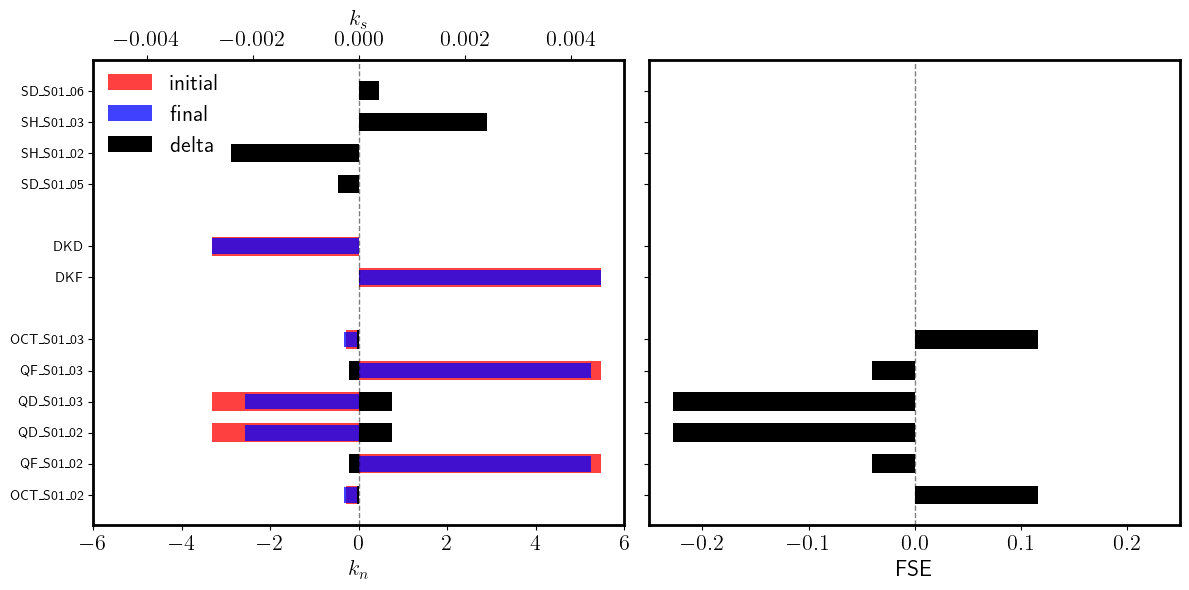

In [46]:
import numpy as np
import matplotlib.pyplot as plt

gap = 1

n_kn = len(dkn_abs)
n_dk = len(gk_abs)
n_ks = len(dks_abs)

y_kn = np.arange(n_kn)
y_dk = np.arange(n_dk) + n_kn + gap
y_ks = np.arange(n_ks) + n_kn + n_dk + 2*gap

yticks = np.concatenate([y_kn, y_dk, y_ks])
yticklabels = [*kni.keys()] + [*gk_abs.keys()] + [*ksi.keys()]

fig, (ax_abs, ax_fse) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

ax_abs.barh(y_dk, [gkfi, gkdi], height=0.6, color='red',   alpha=0.75, label='initial')
ax_abs.barh(y_dk, [gkff, gkdf], height=0.5, color='blue',   alpha=0.75, label='final')
ax_abs.barh(y_dk, [gk_abs['DKF'], gk_abs['DKD']], height=0.6, color='black',   alpha=1, label='delta')

ax_abs.barh(y_kn, kni.values(), height=0.6, color='red',   alpha=0.75)
ax_abs.barh(y_kn, knf.values(), height=0.5, color='blue',   alpha=0.75)
ax_abs.barh(y_kn, list(dkn_abs.values()), height=0.6, color='black', alpha=1)
ax_abs.legend(loc=(0.01, 0.775), frameon=False, fontsize=16, ncol=1)
ax_abs.set_xlim(-6, 6)
ax_abs.set_xlabel(r'$k_n$', fontsize=16)
ax_abs.tick_params(axis='x', labelsize=16)
ax_abs = ax_abs.twiny()
ax_abs.barh(y_ks, ksi.values(), height=0.6, color='red',   alpha=0.75)
ax_abs.barh(y_ks, ksf.values(), height=0.5, color='blue',   alpha=0.75)
ax_abs.barh(y_ks, list(dks_abs.values()), height=0.6, color='black', alpha=1)
ax_abs.set_xlim(-0.005, 0.005)
ax_abs.set_yticks(yticks)
ax_abs.set_yticklabels(yticklabels, fontsize=16)
ax_abs.axvline(0.0, color='black', linewidth=1.0, linestyle='--', alpha=0.5)
ax_abs.set_xlabel(r'$k_s$', fontsize=16)
ax_abs.tick_params(axis='x', labelsize=16)
ax_abs.tick_params(axis='y', labelsize=16)

ax_fse.barh(y_dk, gk_fse.values(), height=0.6, color='black',  alpha=1)
ax_fse.barh(y_kn, dkn_fse.values(), height=0.6, color='black',   alpha=1)
ax_fse.set_xlim(-25/100, 25/100)
ax_fse.axvline(0.0, color='black', linewidth=1.0, linestyle='--', alpha=0.5)
ax_fse.set_xlabel(r'FSE', fontsize=16)
ax_fse.tick_params(axis='x', labelsize=16)
ax_fse.tick_params(axis='y', labelsize=16)

plt.setp(ax_abs.spines.values(), linewidth=2.0)
plt.setp(ax_fse.spines.values(), linewidth=2.0)

plt.tight_layout()
plt.show()

### advance (local)

In [1]:
# Import

import torch
from torch import Tensor

from pathlib import Path

import matplotlib
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
matplotlib.rcParams['text.usetex'] = True

from model.library.element import Element
from model.library.line import Line
from model.library.quadrupole import Quadrupole
from model.library.matrix import Matrix

from model.command.external import load_lattice
from model.command.build import build
from model.command.tune import tune
from model.command.tune import chromaticity
from model.command.orbit import dispersion
from model.command.twiss import twiss
from model.command.advance import advance
from model.command.coupling import coupling

from model.command.wrapper import Wrapper
from model.command.wrapper import forward
from model.command.wrapper import inverse
from model.command.wrapper import normalize

In [2]:
# Set data type and device

Element.dtype = dtype = torch.float64
Element.device = device = torch.device('cpu')

In [3]:
# Load lattice (ELEGANT table)
# Note, lattice is allowed to have repeated elements

path = Path('elettra.lte')
data = load_lattice(path)

In [4]:
# Build and setup lattice

ring:Line = build('RING', 'ELEGANT', data)

# Flatten sublines

ring.flatten()

# Remove all marker elements but the ones starting with MLL (long straight section centers)

ring.remove_group(pattern=r'^(?!MLL_).*', kinds=['Marker'])

# Replace all sextupoles with quadrupoles

def factory(element:Element) -> None:
    table = element.serialize
    table.pop('ms', None)
    return Quadrupole(**table)

ring.replace_group(pattern=r'', factory=factory, kinds=['Sextupole'])

# Set linear dipoles

def apply(element:Element) -> None:
    element.linear = True

ring.apply(apply, kinds=['Dipole'])

# Merge drifts

ring.merge()

# Change lattice start

ring.start = "BPM_S01_01"

# Split BPMs

ring.split((None, ['BPM'], None, None))

# Roll lattice

ring.roll(1)

# Splice lattice

ring.splice()

# Describe

ring.describe

{'BPM': 168, 'Drift': 708, 'Dipole': 156, 'Quadrupole': 360, 'Marker': 12}

In [5]:
# Compute tunes (fractional part)

nux, nuy = tune(ring, [], matched=True, limit=1)

In [6]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx, etapx, etaqy, etapy = dispersion(ring, orbit, [], limit=1)

In [7]:
# Compute twiss parameters

ax, bx, ay, by = twiss(ring, [], matched=True, advance=True, full=False).T

In [8]:
# Compute phase advances

mux, muy = advance(ring, [], alignment=False, matched=True).T

In [9]:
# Compute coupling

c = coupling(ring, [])

In [10]:
# Compute chromaticity

psi = chromaticity(ring, [])

In [11]:
# Quadrupole names for global tune correction

QF = [f'QF_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]
QD = [f'QD_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]

In [12]:
# Global tune responce matrix

def global_observable(knobs):
    kf, kd = knobs
    kn = torch.stack(len(QF)*[kf] + len(QD)*[kd])
    return tune(ring, [kn], ('kn', None, QF + QD, None), matched=True, limit=1)

knobs = torch.tensor([0.0, 0.0], dtype=dtype)
global_target = global_observable(knobs)
global_matrix = torch.func.jacfwd(global_observable)(knobs)

print(global_target)
print(global_matrix)

tensor([0.2994, 0.1608], dtype=torch.float64)
tensor([[ 5.8543,  2.0964],
        [-2.9918, -1.2602]], dtype=torch.float64)


In [13]:
# Several local knobs can be used to correct ID effects

# Normal quadrupole correctors

nkn = ['OCT_S01_02', 'QF_S01_02', 'QD_S01_02', 'QD_S01_03', 'QF_S01_03', 'OCT_S01_03']

# Skew quadrupole correctors

nks = ['SD_S01_05', 'SH_S01_02', 'SH_S01_03', 'SD_S01_06']

In [14]:
# Define knobs to magnets mixing matrices

Sn = torch.tensor([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0], [0.0, 0.0, 1.0], [0.0, 1.0, 0.0], [1.0, 0.0, 0.0]], dtype=dtype)

print(Sn)
print()

Ss = torch.tensor([[+1.0, 0.0], [0.0, +1.0], [0.0, -1.0], [-1.0, 0.0]], dtype=dtype)

print(Ss)
print()

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.]], dtype=torch.float64)

tensor([[ 1.,  0.],
        [ 0.,  1.],
        [ 0., -1.],
        [-1.,  0.]], dtype=torch.float64)



In [15]:
# Define advance observable

def observable_advance(kn, ks):
    return advance(ring, 
                   [kn, ks], 
                   ('kn', None, nkn, None), 
                   ('ks', None, nks, None), 
                   matched=True)

In [16]:
# Define dispersion observable

def observable_dispersion(kn, ks):  
    orbit = torch.tensor(4*[0.0], dtype=dtype)
    etax, _, etay, _ = dispersion(ring, 
                                  orbit,
                                  [kn, ks],
                                  ('kn', None, nkn, None),
                                  ('ks', None, nks, None))
    return torch.stack([etax, etay]).T

In [17]:
# Construct full target observable vector and corresponding responce matrix

def observable(knobs):
    kn, ks = torch.split(knobs, [3, 2])
    kn = Sn @ kn
    ks = Ss @ ks    
    betas = observable_advance(kn, ks)
    etas = observable_dispersion(kn, ks)
    return torch.cat([betas.flatten(), etas.flatten()])

knobs = torch.tensor((3 + 2)*[0.0], dtype=dtype)
print((target := observable(knobs)).shape)
print((matrix := torch.func.jacfwd(observable)(knobs)).shape)

torch.Size([672])
torch.Size([672, 5])


In [18]:
# Define ID model
# Note, only the flattened triangular part of the A and B matrices is passed

A = torch.tensor([[-0.03484222052711237, 1.0272120741819959E-7, -4.698931299341201E-9, 0.0015923185492594811],
                  [1.0272120579834892E-7, -0.046082787920135176, 0.0017792061173117564, 3.3551298301095784E-8],
                  [-4.6989312853101E-9, 0.0017792061173117072, 0.056853750760983084, -1.5929605363332683E-7],
                  [0.0015923185492594336, 3.3551298348653296E-8, -1.5929605261642905E-7, 0.08311631737263032]], dtype=dtype)

B = torch.tensor([[0.03649353186115209, 0.0015448347221877217, 0.00002719892025520868, -0.0033681183134964482],
                  [0.0015448347221877217, 0.13683886657005795, -0.0033198692682377406, 0.00006140578258682469],
                  [0.00002719892025520868, -0.0033198692682377406, -0.05260095308967722, 0.005019907688182885],
                  [-0.0033681183134964482, 0.00006140578258682469, 0.005019907688182885, -0.2531573249456863]], dtype=dtype)

ID = Matrix('ID', 
            length=0.0, 
            A=A[torch.triu(torch.ones_like(A, dtype=torch.bool))].tolist(), 
            B=B[torch.triu(torch.ones_like(B, dtype=torch.bool))].tolist())

In [19]:
# Insert ID into the existing lattice
# This will replace the target marker

error = ring.clone()
error.flatten()
error.insert(ID, error.next('MLL_S01').name, position=0.0)
error.splice()

# Describe

error.describe

{'BPM': 168,
 'Drift': 709,
 'Dipole': 156,
 'Quadrupole': 360,
 'Marker': 12,
 'Matrix': 1}

In [20]:
# Compute tunes (fractional part)

nux_id, nuy_id = tune(error, [], matched=True, limit=1)

In [21]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id, etapx_id, etaqy_id, etapy_id = dispersion(error, orbit, [], limit=1)

In [22]:
# Compute twiss parameters

ax_id, bx_id, ay_id, by_id = twiss(error, [], matched=True, advance=True, full=False).T

In [23]:
# Compute phase advances

mux_id, muy_id = advance(error, [], alignment=False, matched=True).T

In [24]:
# Compute coupling

c_id = coupling(error, [])

In [25]:
# Compute hromaticity

psi_id = chromaticity(error, [])

In [26]:
# Tune shifts

print((nux - nux_id))
print((nuy - nuy_id))

tensor(0.0260, dtype=torch.float64)
tensor(-0.0114, dtype=torch.float64)


In [27]:
# Coupling (minimal tune distance)

print(c)
print(c_id)

tensor(0., dtype=torch.float64)
tensor(0.0004, dtype=torch.float64)


In [28]:
# Chromaticity

print(psi)
print(psi_id)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-72.2597, -66.6681], dtype=torch.float64)


In [29]:
# Define parametric observable vector

def global_observable(knobs):
    kf, kd = knobs
    kn = torch.stack(len(QF)*[kf] + len(QD)*[kd])
    return tune(error, [kn], ('kn', None, QF + QD, None), matched=True, limit=1)

def observable_advance(kn, ks):
    return advance(error, 
                   [kn, ks], 
                   ('kn', None, nkn, None), 
                   ('ks', None, nks, None), 
                   matched=True)

def observable_dispersion(kn, ks):
    orbit = torch.tensor(4*[0.0], dtype=dtype)
    etax, _, etay, _ = dispersion(error, 
                                  orbit,
                                  [kn, ks],
                                  ('kn', None, nkn, None),
                                  ('ks', None, nks, None))
    return torch.stack([etax, etay]).T


def observable(knobs):
    kn, ks = torch.split(knobs, [3, 2])
    kn = Sn @ kn
    ks = Ss @ ks  
    betas = observable_advance(kn, ks)
    etas = observable_dispersion(kn, ks)
    return torch.cat([betas.flatten(), etas.flatten()])

In [30]:
# Check the residual vector norm

global_knobs = torch.tensor(2*[0.0], dtype=dtype)
knobs = torch.tensor((3 + 2)*[0.0], dtype=dtype)

print(((global_observable(global_knobs) - global_target)**2).sum())
print(((observable(knobs) - target)**2).sum())

tensor(0.0008, dtype=torch.float64)
tensor(0.4812, dtype=torch.float64)


In [31]:
# Optimization loop (local)

# Responce matrix (jacobian)

M = matrix.clone()

# Weighting covariance (sensitivity) matrix

epsilon = 1.0E-9
C = M @ M.T
C = C + epsilon*torch.eye(len(C), dtype=dtype)

# Cholesky decomposition

L = torch.linalg.cholesky(C) 

# Whiten response

M = torch.linalg.solve_triangular(L, M, upper=False)

# Additional weights
# Can be used to extra weight selected observables, e.g. tunes

weights = torch.ones(len(M), dtype=dtype)
weights = weights.sqrt()

# Whiten response with additional weights

M = M*weights.unsqueeze(1)

# Iterative correction

lr = 0.75

# Initial value

knobs = torch.tensor((3 + 2)*[0.0], dtype=dtype)

# Correction loop

for _ in range(8):
    value = observable(knobs)
    residual = target - value
    residual = torch.linalg.solve_triangular(L, residual.unsqueeze(-1), upper=False).squeeze(-1)
    residual = residual*weights
    delta = torch.linalg.lstsq(M, residual, driver="gels").solution
    knobs += lr*delta
    print(((value - target)**2).sum())
print()

tensor(0.4812, dtype=torch.float64)
tensor(0.0262, dtype=torch.float64)
tensor(0.0007, dtype=torch.float64)
tensor(0.0001, dtype=torch.float64)
tensor(0.0001, dtype=torch.float64)
tensor(0.0001, dtype=torch.float64)
tensor(0.0001, dtype=torch.float64)
tensor(0.0001, dtype=torch.float64)



In [32]:
# Knob values

kn, ks = torch.split(knobs, [3, 2])

kn = Sn @ kn
ks = Ss @ ks

print(kn.numpy())
print(ks.numpy())

[-0.03953849 -0.18218742  0.65489026  0.65489026 -0.18218742 -0.03953849]
[-3.65464381e-09 -2.14039357e-03  2.14039357e-03  3.65464381e-09]


In [33]:
# Apply final corrections

error.flatten()

print()
print('kn:')
for name, knob in zip(nkn, kn):
    print(f'{name:<10}: {knob.numpy():>20}: {error[name].kn.numpy():>20} -> {(error[name].kn + knob).numpy():>20}, FSE: {((error[name].kn + knob)/error[name].kn - 1).numpy():>20}')
    error[name].kn = (error[name].kn + knob).item()

print()
print('ks:')
for name, knob in zip(nks, ks):
    print(f'{name:<10}: {knob.numpy():>20}: {error[name].ks.numpy():>20} -> {(error[name].ks + knob).numpy():>20}')
    error[name].ks = (error[name].ks + knob).item()
    
error.splice()


kn:
OCT_S01_02: -0.03953849341840344: -0.29359999999999903 -> -0.33313849341840246, FSE:   0.1346678931144536
QF_S01_02 : -0.18218742155108172:    5.479408293511701 ->    5.297220871960619, FSE: -0.03324946997777378
QD_S01_02 :   0.6548902571935666:   -3.319999999999998 ->  -2.6651097428064316, FSE: -0.19725610156432738
QD_S01_03 :   0.6548902571935666:   -3.319999999999998 ->  -2.6651097428064316, FSE: -0.19725610156432738
QF_S01_03 : -0.18218742155108172:    5.479408293511701 ->    5.297220871960619, FSE: -0.03324946997777378
OCT_S01_03: -0.03953849341840344: -0.29359999999999903 -> -0.33313849341840246, FSE:   0.1346678931144536

ks:
SD_S01_05 : -3.65464380817924e-09:                  0.0 -> -3.65464380817924e-09
SH_S01_02 : -0.002140393567505922:                  0.0 -> -0.002140393567505922
SH_S01_03 : 0.002140393567505922:                  0.0 -> 0.002140393567505922
SD_S01_06 : 3.65464380817924e-09:                  0.0 -> 3.65464380817924e-09


In [34]:
# Check 

print(((global_observable(0.0*global_knobs) - global_target)**2).sum())
print(((observable(0.0*knobs) - target)**2).sum())

tensor(6.9220e-06, dtype=torch.float64)
tensor(0.0001, dtype=torch.float64)


In [35]:
# Compute tunes (fractional part)

nux_result, nuy_result = tune(error, [], matched=True, limit=1)

In [36]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_result, etapx_result, etaqy_result, etapy_result = dispersion(error, orbit, [], limit=1)

In [37]:
# Compute twiss parameters

ax_result, bx_result, ay_result, by_result = twiss(error, [], matched=True, advance=True, full=False).T

In [38]:
# Compute phase advances

mux_result, muy_result = advance(error, [], alignment=False, matched=True).T

In [39]:
# Compute coupling

c_result = coupling(error, [])

In [40]:
# Compute chromaticity

psi_result = chromaticity(error, [])

In [41]:
# Tune shifts

print((nux - nux_id).abs())
print((nuy - nuy_id).abs())
print()

print((nux - nux_result).abs())
print((nuy - nuy_result).abs())
print()

tensor(0.0260, dtype=torch.float64)
tensor(0.0114, dtype=torch.float64)

tensor(0.0011, dtype=torch.float64)
tensor(0.0024, dtype=torch.float64)



In [42]:
# Coupling (minimal tune distance)

print(c)
print(c_id)
print(c_result)

tensor(0., dtype=torch.float64)
tensor(0.0004, dtype=torch.float64)
tensor(4.0273e-05, dtype=torch.float64)


In [43]:
# Chromaticity

(psi_x, psi_y) = psi
(psi_id_x, psi_id_y) = psi_id
(psi_result_x, psi_result_y) =psi_result

print(psi_x, psi_y)
print(psi_id_x, psi_id_y)
print(psi_result_x, psi_result_y)

tensor(-71.2093, dtype=torch.float64) tensor(-66.6787, dtype=torch.float64)
tensor(-72.2597, dtype=torch.float64) tensor(-66.6681, dtype=torch.float64)
tensor(-71.1746, dtype=torch.float64) tensor(-66.6894, dtype=torch.float64)


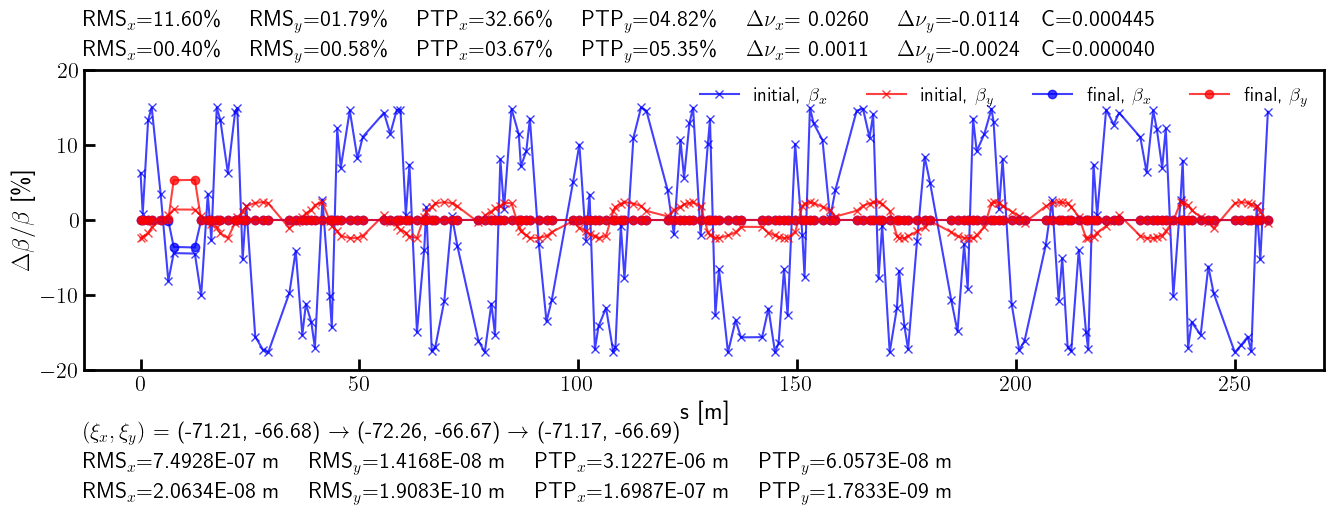

In [44]:
# Beta-beating

bx_ref_bb = 100.0*(bx - bx_id)    / bx
by_ref_bb = 100.0*(by - by_id)    / by
bx_res_bb = 100.0*(bx - bx_result)/ bx
by_res_bb = 100.0*(by - by_result)/ by

def rms(x):
    return (x**2).mean().sqrt()

rms_x_ref = rms(bx_ref_bb).item()
ptp_x_ref = (bx_ref_bb.max() - bx_ref_bb.min()).item()
rms_y_ref = rms(by_ref_bb).item()
ptp_y_ref = (by_ref_bb.max() - by_ref_bb.min()).item()

rms_x_res = rms(bx_res_bb).item()
ptp_x_res = (bx_res_bb.max() - bx_res_bb.min()).item()
rms_y_res = rms(by_res_bb).item()
ptp_y_res = (by_res_bb.max() - by_res_bb.min()).item()

s = ring.locations().cpu().numpy()
bx_ref_np = bx_ref_bb.cpu().numpy()
by_ref_np = by_ref_bb.cpu().numpy()
bx_res_np = bx_res_bb.cpu().numpy()
by_res_np = by_res_bb.cpu().numpy()

etax_ref = etaqx - etaqx_id
etay_ref = etaqy - etaqy_id
etax_res = etaqx - etaqx_result
etay_res = etaqy - etaqy_result

rms_etax_ref = rms(etax_ref).item()
ptp_etax_ref = (etax_ref.max() - etax_ref.min()).item()
rms_etay_ref = rms(etay_ref).item()
ptp_etay_ref = (etay_ref.max() - etay_ref.min()).item()

rms_etax_res = rms(etax_res).item()
ptp_etax_res = (etax_res.max() - etax_res.min()).item()
rms_etay_res = rms(etay_res).item()
ptp_etay_res = (etay_res.max() - etay_res.min()).item()

etax_ref_np = etax_ref.cpu().numpy()
etay_ref_np = etay_ref.cpu().numpy()
etax_res_np = etax_res.cpu().numpy()
etay_res_np = etay_res.cpu().numpy()


fig, ax = plt.subplots(
    1, 1, figsize=(16, 6),
    sharex=True,
    gridspec_kw={'hspace': 0.3}
)

fig.subplots_adjust(top=0.85, bottom=0.35)

ax.errorbar(s, bx_ref_np, fmt='-', marker='x', color='blue', alpha=0.75, lw=1.5, label=r'initial, $\beta_x$')
ax.errorbar(s, by_ref_np, fmt='-', marker='x', color='red',  alpha=0.75, lw=1.5, label=r'initial, $\beta_y$')
ax.errorbar(s, bx_res_np, fmt='-', marker='o', color='blue', alpha=0.75, lw=1.5, label=r'final, $\beta_x$')
ax.errorbar(s, by_res_np, fmt='-', marker='o', color='red',  alpha=0.75, lw=1.5, label=r'final, $\beta_y$')
ax.set_xlabel('s [m]', fontsize=18)
ax.set_ylabel(r'$\Delta \beta / \beta$ [\%]', fontsize=18)
ax.tick_params(width=2, labelsize=16)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')
title = (
    rf'RMS$_x$={rms_x_ref:05.2f}\% \quad RMS$_y$={rms_y_ref:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_ref:05.2f}\% \quad PTP$_y$={ptp_y_ref:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_id)}{(nux - nux_id).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_id)}{(nuy - nuy_id).abs().item():.4f}'
    rf'\quad C={c_id.item():.6f}'
)
ax.text(0.0, 1.125, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'RMS$_x$={rms_x_res:05.2f}\% \quad RMS$_y$={rms_y_res:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_res:05.2f}\% \quad PTP$_y$={ptp_y_res:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_result)}{(nux - nux_result).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_result)}{(nuy - nuy_result).abs().item():.4f}'
    rf'\quad C={c_result.item():.6f}'
)
ax.text(0.0, 1.025, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'$(\xi_x, \xi_y)$ = ({psi_x.item():.2f}, {psi_y.item():.2f}) $\to$ ({psi_id_x.item():.2f}, {psi_id_y.item():.2f}) $\to$ ({psi_result_x.item():.2f}, {psi_result_y.item():.2f})' 
)
ax.text(0.0, -0.25 - 0*0.1, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'RMS$_x$={rms_etax_ref:.4E} m \quad RMS$_y$={rms_etay_ref:.4E} m  \quad '
    rf'PTP$_x$={ptp_etax_ref:.4E} m \quad PTP$_y$={ptp_etay_ref:.4E} m  \quad '
)
ax.text(0.0, -0.25 - 1*0.1, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'RMS$_x$={rms_etax_res:.4E} m  \quad RMS$_y$={rms_etay_res:.4E} m  \quad '
    rf'PTP$_x$={ptp_etax_res:.4E} m  \quad PTP$_y$={ptp_etay_res:.4E} m  \quad '
)
ax.text(0.0, -0.25 - 2*0.1, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

ax.legend(loc='upper right', frameon=False, fontsize=14, ncol=4)
ax.set_ylim(-20, 20)

plt.setp(ax.spines.values(), linewidth=2.0)
plt.show()

In [45]:
# Initial and final values

QF = [f'QF_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]
QD = [f'QD_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]

nkn = ['OCT_S01_02', 'QF_S01_02', 'QD_S01_02', 'QD_S01_03', 'QF_S01_03', 'OCT_S01_03']
nks = ['SD_S01_05', 'SH_S01_02', 'SH_S01_03', 'SD_S01_06']

ring.flatten()

kni = {name: ring[name].kn.item() for name in nkn}
ksi = {name: ring[name].ks.item() for name in nks}
kfi = {name: ring[name].kn.item() for name in QF}
kdi = {name: ring[name].kn.item() for name in QD}

ring.splice()

error.flatten()

knf = {name: error[name].kn.item() for name in nkn}
ksf = {name: error[name].ks.item() for name in nks}
kff = {name: error[name].kn.item() for name in QF}
kdf = {name: error[name].kn.item() for name in QD}

error.splice()

In [46]:
# Global

gkfi = [kfi[name] for name in kfi if name not in nkn]
gkdi = [kdi[name] for name in kdi if name not in nkn]
gkfi, *_ = gkfi
gkdi, *_ = gkdi

gkff = [kff[name] for name in kff if name not in nkn]
gkdf = [kdf[name] for name in kdf if name not in nkn]
gkff, *_ = gkff
gkdf, *_ = gkdf

dkf = [(kff[name] - kfi[name]) for name in kfi if name not in nkn]
dkd = [(kdf[name] - kdi[name]) for name in kdi if name not in nkn]
dkf_abs, *_ = dkf
dkd_abs, *_ = dkd
gk_abs = {'DKF': dkf_abs, 'DKD': dkd_abs}

dkf = [(kff[name]/kfi[name] - 1) for name in kfi if name not in nkn]
dkd = [(kdf[name]/kdi[name] - 1) for name in kdi if name not in nkn]
dkf_fse, *_ = dkf
dkd_fse, *_ = dkd
gk_fse = {'DKF': dkf_fse, 'DKD': dkd_fse}

print(gk_abs)
print(gk_fse)

{'DKF': 0.0, 'DKD': 0.0}
{'DKF': 0.0, 'DKD': 0.0}


In [47]:
# Local

dkn_fse = {name: knf[name]/kni[name] - 1 for name in kni}
dkn_abs = {name: knf[name] - kni[name]for name in kni}

dks_fse = {name: 0 for name in ksi}
dks_abs = {name: ksf[name] - ksi[name] for name in ksi}

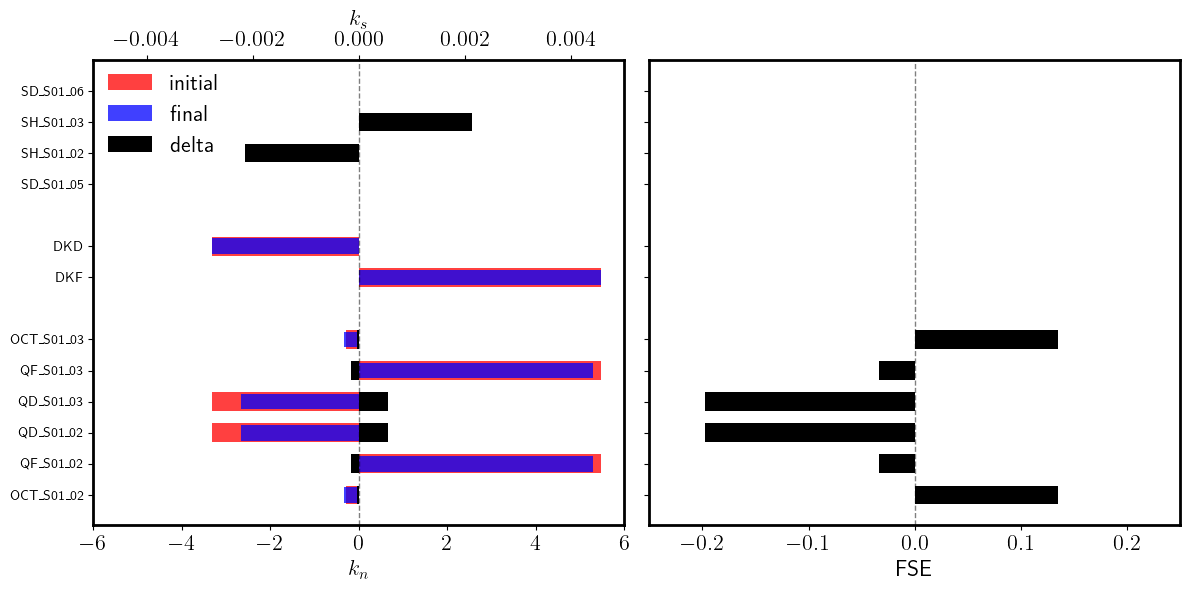

In [48]:
import numpy as np
import matplotlib.pyplot as plt

gap = 1

n_kn = len(dkn_abs)
n_dk = len(gk_abs)
n_ks = len(dks_abs)

y_kn = np.arange(n_kn)
y_dk = np.arange(n_dk) + n_kn + gap
y_ks = np.arange(n_ks) + n_kn + n_dk + 2*gap

yticks = np.concatenate([y_kn, y_dk, y_ks])
yticklabels = [*kni.keys()] + [*gk_abs.keys()] + [*ksi.keys()]

fig, (ax_abs, ax_fse) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

ax_abs.barh(y_dk, [gkfi, gkdi], height=0.6, color='red',   alpha=0.75, label='initial')
ax_abs.barh(y_dk, [gkff, gkdf], height=0.5, color='blue',   alpha=0.75, label='final')
ax_abs.barh(y_dk, [gk_abs['DKF'], gk_abs['DKD']], height=0.6, color='black',   alpha=1, label='delta')

ax_abs.barh(y_kn, kni.values(), height=0.6, color='red',   alpha=0.75)
ax_abs.barh(y_kn, knf.values(), height=0.5, color='blue',   alpha=0.75)
ax_abs.barh(y_kn, list(dkn_abs.values()), height=0.6, color='black', alpha=1)
ax_abs.legend(loc=(0.01, 0.775), frameon=False, fontsize=16, ncol=1)
ax_abs.set_xlim(-6, 6)
ax_abs.set_xlabel(r'$k_n$', fontsize=16)
ax_abs.tick_params(axis='x', labelsize=16)
ax_abs = ax_abs.twiny()
ax_abs.barh(y_ks, ksi.values(), height=0.6, color='red',   alpha=0.75)
ax_abs.barh(y_ks, ksf.values(), height=0.5, color='blue',   alpha=0.75)
ax_abs.barh(y_ks, list(dks_abs.values()), height=0.6, color='black', alpha=1)
ax_abs.set_xlim(-0.005, 0.005)
ax_abs.set_yticks(yticks)
ax_abs.set_yticklabels(yticklabels, fontsize=16)
ax_abs.axvline(0.0, color='black', linewidth=1.0, linestyle='--', alpha=0.5)
ax_abs.set_xlabel(r'$k_s$', fontsize=16)
ax_abs.tick_params(axis='x', labelsize=16)
ax_abs.tick_params(axis='y', labelsize=16)

ax_fse.barh(y_dk, gk_fse.values(), height=0.6, color='black',  alpha=1)
ax_fse.barh(y_kn, dkn_fse.values(), height=0.6, color='black',   alpha=1)
ax_fse.set_xlim(-25/100, 25/100)
ax_fse.axvline(0.0, color='black', linewidth=1.0, linestyle='--', alpha=0.5)
ax_fse.set_xlabel(r'FSE', fontsize=16)
ax_fse.tick_params(axis='x', labelsize=16)
ax_fse.tick_params(axis='y', labelsize=16)

plt.setp(ax_abs.spines.values(), linewidth=2.0)
plt.setp(ax_fse.spines.values(), linewidth=2.0)

plt.tight_layout()
plt.show()